# 🍽️ 자취생의 냉털을 부탁해! 🍽️


## 0. 환경 설정


In [1]:
import importlib.util
import subprocess
import sys
from importlib.metadata import version
from packaging.version import Version
packages = {'gensim': 'gensim>=4.4.0', 'transformers': 'transformers', 'huggingface_hub': 'huggingface-hub', 'seaborn': 'seaborn', 'scipy': 'scipy', 'sklearn': 'scikit-learn', 'tqdm': 'tqdm'}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if importlib.util.find_spec('gensim') is not None and Version(version('gensim')) < Version('4.4.0'):
    missing.append('gensim>=4.4.0')
if Version(version('torch')) < Version('2.6.0'):
    missing.append('torch>=2.6.0')
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])


In [2]:
from google.colab import drive
from pathlib import Path
import torch
from IPython.display import display
from tqdm.auto import tqdm
drive.mount('/content/drive')
print('사용 장치:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
if not torch.cuda.is_available():
    print('감성분석 속도를 위해 런타임 유형에서 GPU를 선택하세요.')

Mounted at /content/drive
사용 장치: Tesla T4


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
DATA_DIR = Path('/content/drive/MyDrive/DartB_Dana/data')
OUTPUT_DIR = DATA_DIR.parent / 'outputs' / 'final_analysis'
FIGURE_DIR = OUTPUT_DIR / 'figures'
CACHE_DIR = OUTPUT_DIR / 'cache'
for folder in [OUTPUT_DIR, FIGURE_DIR, CACHE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

#### 분석 설정값


In [5]:
SEED = 42
MAX_MINUTES = 60
CLUSTER_K_VALUES = [5, 6]
CLUSTER_K = 6  # EDA용
CLUSTER_NAMES = {}  # 키: 0~5, 실행 결과 확인 후 입력
SENTIMENT_MODEL = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
SENTIMENT_DEVICE = 0 if torch.cuda.is_available() else -1
SENTIMENT_BATCH_SIZE = 16
BAYES_PRIOR_QUANTILE = 0.50
NUTRITION_COLS = [
    'calories', 'total_fat_pdv', 'sugar_pdv', 'sodium_pdv',
    'protein_pdv', 'saturated_fat_pdv', 'carbohydrates_pdv'
]
CATEGORY_COLS = ['course_category', 'dish_type', 'main_ingredient_group', 'cuisine']
PANTRY_INGREDIENTS = {
    'salt', 'water', 'butter', 'olive oil', 'vegetable oil',
    'black pepper', 'sugar', 'flour', 'garlic', 'onion'
}

In [6]:
font_path = Path('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
if not font_path.exists():
    subprocess.run(['apt-get', '-qq', 'update'], check=True)
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], check=True)
font_manager.fontManager.addfont(str(font_path))

In [7]:
# 시각화 설정
import seaborn as sns
sns.set_theme(style='whitegrid')
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font in ['AppleGothic', 'Malgun Gothic', 'NanumGothic', 'DejaVu Sans']:
    if font in available_fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', 30)

In [8]:
# 공통저장 파싱함수
import ast
def save_figure(fig, name):
    fig.savefig(FIGURE_DIR / f'{name}.png', dpi=220, bbox_inches='tight')
    fig.savefig(FIGURE_DIR / f'{name}.svg', bbox_inches='tight')
def parse_list(value):
    if isinstance(value, (list, tuple)):
        return list(value)
    if pd.isna(value) or not str(value).strip():
        return []
    try:
        result = ast.literal_eval(str(value))
    except (ValueError, SyntaxError):
        return []
    return list(result) if isinstance(result, (list, tuple)) else []

In [9]:
# 재료명 정규화
INGREDIENT_ALIASES = {
    'eggs': 'egg', 'egg whites': 'egg white', 'egg yolks': 'egg yolk',
    'onions': 'onion', 'diced onion': 'onion', 'red onions': 'red onion',
    'yellow onions': 'yellow onion', 'white onions': 'white onion',
    'sweet onions': 'sweet onion', 'green onions': 'green onion',
    'eggplants': 'eggplant', 'shredded cheddar cheese': 'cheddar cheese'
}
def normalize_ingredient(value):
    value = ' '.join(str(value).lower().split())
    return INGREDIENT_ALIASES.get(value, value)
def normalize_ingredients(items):
    return sorted({normalize_ingredient(x) for x in items if isinstance(x, str) and x.strip()})

## 1️⃣ EDA
### 1-1. 데이터 구조와 결측치


In [10]:
required_files = ['RAW_recipes.csv', 'RAW_interactions.csv', 'recipe_metadata_final.csv']
missing_files = [name for name in required_files if not (DATA_DIR / name).is_file()]
if missing_files:
    raise FileNotFoundError(f'{DATA_DIR}: {missing_files}')
recipes_raw = pd.read_csv(DATA_DIR / 'RAW_recipes.csv', encoding='utf-8-sig')
interactions_raw = pd.read_csv(DATA_DIR / 'RAW_interactions.csv', encoding='utf-8-sig')
interactions_raw.insert(0, 'interaction_id', np.arange(len(interactions_raw), dtype=np.int64))
assert recipes_raw['id'].notna().all() and recipes_raw['id'].is_unique
assert interactions_raw['rating'].notna().all()
assert interactions_raw['rating'].isin(range(6)).all()

#### Dataset 크기

In [11]:
from IPython.display import display
display(pd.DataFrame({
    '데이터': ['recipes', 'interactions'],
    '행': [len(recipes_raw), len(interactions_raw)],
    '열': [recipes_raw.shape[1], interactions_raw.shape[1] - 1]
}))

,데이터,행,열
0,recipes,231637,12
1,interactions,1132367,5


#### 컬럼 자료형&결측치 점검

In [12]:
for name, frame in [('recipes', recipes_raw), ('interactions', interactions_raw)]:
    print(name)
    display(pd.DataFrame({
        'dtype': frame.dtypes.astype(str),
        'missing': frame.isna().sum(),
        'missing_pct': frame.isna().mean() * 100
    }))

recipes


,dtype,missing,missing_pct
name,object,1,0.000432
id,int64,0,0.000000
minutes,int64,0,0.000000
contributor_id,int64,0,0.000000
submitted,object,0,0.000000
tags,object,0,0.000000
nutrition,object,0,0.000000
n_steps,int64,0,0.000000
steps,object,0,0.000000
description,object,4979,2.149484


interactions


,dtype,missing,missing_pct
interaction_id,int64,0,0.000000
user_id,int64,0,0.000000
recipe_id,int64,0,0.000000
date,object,0,0.000000
rating,int64,0,0.000000
review,object,169,0.014924


#### 중복과 참조 무결성 점검


In [13]:
print('원본 레시피 중복:', recipes_raw.duplicated().sum())
print('원본 리뷰 중복:', interactions_raw.drop(columns='interaction_id').duplicated().sum())
print('레시피에 없는 interaction ID 수:',
      interactions_raw.loc[~interactions_raw['recipe_id'].isin(recipes_raw['id']), 'recipe_id'].nunique())

원본 레시피 중복: 0
원본 리뷰 중복: 0
레시피에 없는 interaction ID 수: 0


In [ ]:
display(recipes_raw.head(3))

### 1-2. 영양성분·리스트 파싱과 원본 평점 집계
칼로리는 kcal, 나머지 영양성분은 일일 권장량 대비 비율(%)


#### 리스트 파싱과 평점 집계


In [14]:
recipes_parsed = recipes_raw.copy()
for col in ['ingredients', 'tags', 'steps']:
    recipes_parsed[f'{col}_list'] = recipes_parsed[col].map(parse_list)
nutrition_values = recipes_parsed['nutrition'].map(parse_list)
invalid_nutrition = nutrition_values.map(len).ne(len(NUTRITION_COLS))
nutrition_values = nutrition_values.map(
    lambda values: values if len(values) == len(NUTRITION_COLS) else [np.nan] * len(NUTRITION_COLS)
)
nutrition_frame = pd.DataFrame(nutrition_values.tolist(), columns=NUTRITION_COLS, index=recipes_parsed.index)
nutrition_frame = nutrition_frame.apply(pd.to_numeric, errors='coerce')
recipes_parsed = pd.concat([recipes_parsed, nutrition_frame], axis=1)
recipes_parsed['submitted'] = pd.to_datetime(recipes_parsed['submitted'], errors='coerce')
interactions_raw['date'] = pd.to_datetime(interactions_raw['date'], errors='coerce')
interactions_raw['has_review'] = interactions_raw['review'].fillna('').str.strip().ne('')
raw_rating_stats = interactions_raw.groupby('recipe_id').agg(
    rating_mean_raw=('rating', 'mean'),
    rating_count_raw=('rating', 'count'),
    interaction_count=('rating', 'size'),
    review_count=('has_review', 'sum')
).rename_axis('id').reset_index()
recipes_eda = recipes_parsed.merge(raw_rating_stats, on='id', how='left', validate='one_to_one')
count_cols = ['rating_count_raw', 'interaction_count', 'review_count']
recipes_eda[count_cols] = recipes_eda[count_cols].fillna(0).astype(int)

#### 파싱 점검과 기술통계표


In [15]:
print('영양성분 파싱 오류:', invalid_nutrition.sum())
display(recipes_eda[['minutes', 'n_steps', 'n_ingredients'] + NUTRITION_COLS + count_cols].describe().T)

영양성분 파싱 오류: 0


,count,mean,std,min,25%,50%,75%,max
minutes,231637.0,9398.546009,4.461963e+06,0.0,20.0,40.0,65.0,2.147484e+09
n_steps,231637.0,9.765499,5.995128e+00,0.0,6.0,9.0,12.0,1.450000e+02
n_ingredients,231637.0,9.051153,3.734796e+00,1.0,6.0,9.0,11.0,4.300000e+01
calories,231637.0,473.942425,1.189711e+03,0.0,174.4,313.4,519.7,4.343602e+05
total_fat_pdv,231637.0,36.080700,7.779884e+01,0.0,8.0,20.0,41.0,1.718300e+04
sugar_pdv,231637.0,84.296865,8.000809e+02,0.0,9.0,25.0,68.0,3.627290e+05
sodium_pdv,231637.0,30.147485,1.319616e+02,0.0,5.0,14.0,33.0,2.933800e+04
protein_pdv,231637.0,34.681860,5.847248e+01,0.0,7.0,18.0,51.0,6.552000e+03
saturated_fat_pdv,231637.0,45.589150,9.823576e+01,0.0,7.0,23.0,52.0,1.039500e+04
carbohydrates_pdv,231637.0,15.560403,8.182456e+01,0.0,4.0,9.0,16.0,3.609800e+04


### 1-3. 수치형 분포와 로그변환 전후 비교


#### 수치형 변수 원본 분포


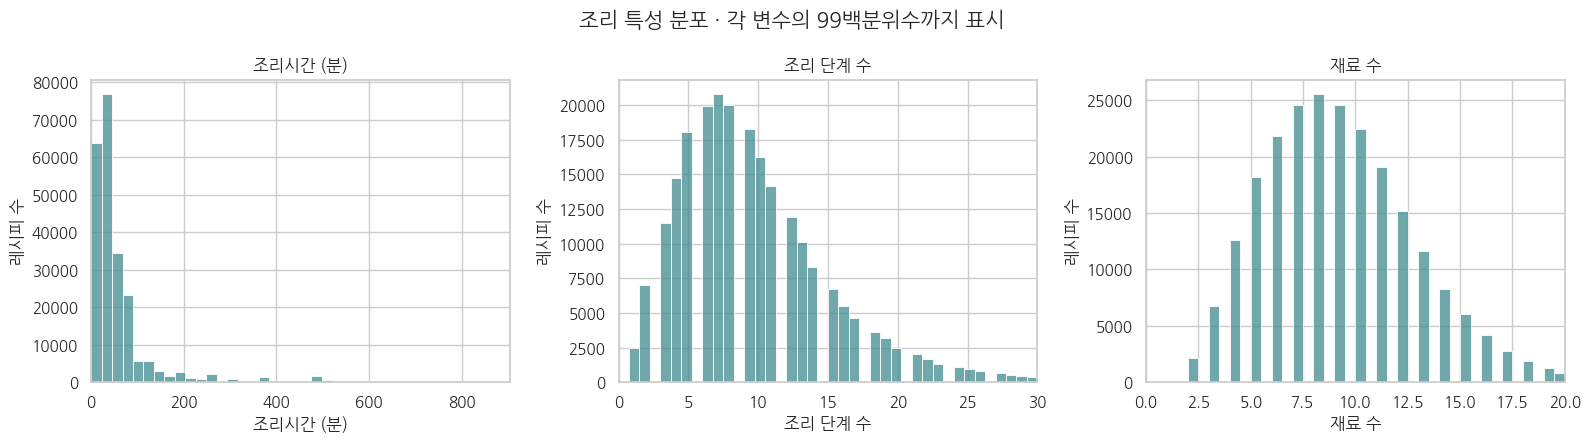

In [16]:
basic_cols = {
    'minutes': '조리시간 (분)',
    'n_steps': '조리 단계 수',
    'n_ingredients': '재료 수',
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, label) in zip(axes, basic_cols.items()):
    values = recipes_eda[col].replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values.ge(0)]
    upper = max(float(values.quantile(0.99)), 1)
    visible = values[values.le(upper)]
    # 표시 범위 안에서 히스토그램 구간을 다시 계산
    sns.histplot(
        visible, bins=40, binrange=(0, upper),
        color='#418b91', ax=ax,
    )
    ax.set(
        title=label,
        xlabel=label,
        ylabel='레시피 수',
        xlim=(0, upper),
    )
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
fig.suptitle('조리 특성 분포 · 각 변수의 99백분위수까지 표시', fontsize=15)
fig.tight_layout()
save_figure(fig, '01_basic_distributions')
plt.show()

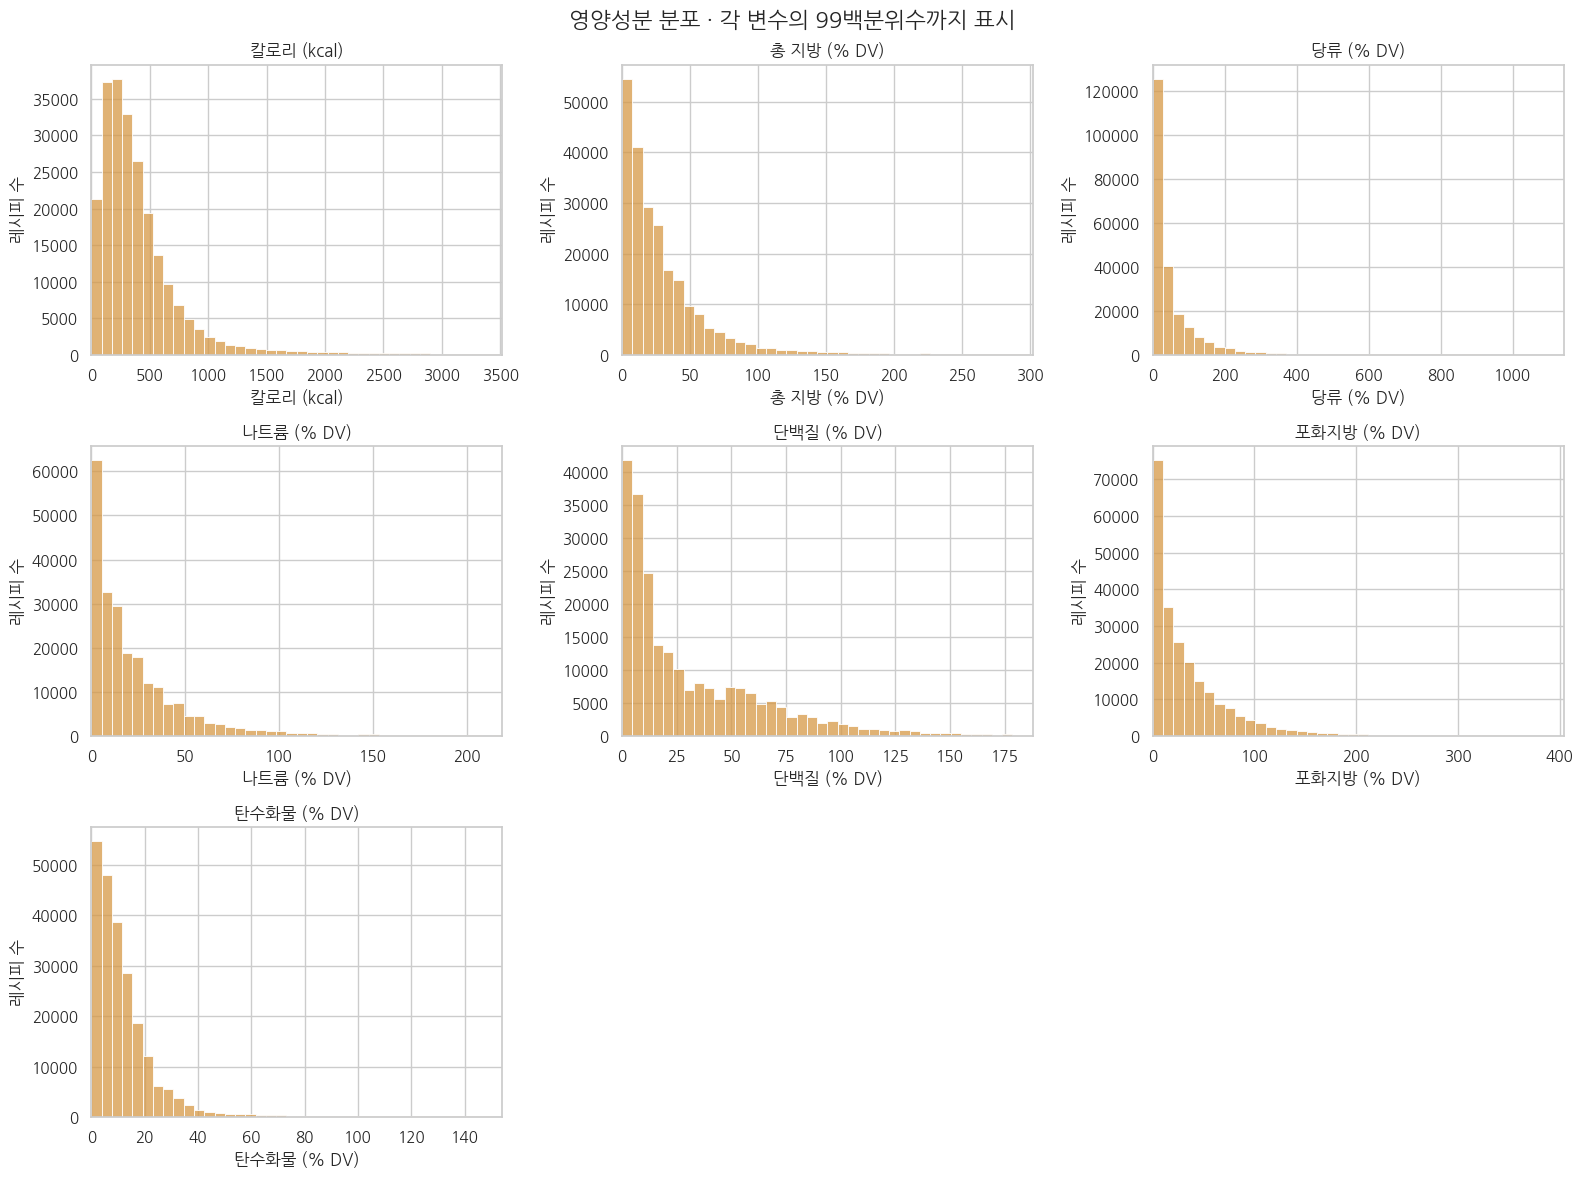

In [17]:
# 영양성분 분포 99% clip 처리
nutrition_labels = {
    'calories': '칼로리 (kcal)',
    'total_fat_pdv': '총 지방 (% DV)',
    'sugar_pdv': '당류 (% DV)',
    'sodium_pdv': '나트륨 (% DV)',
    'protein_pdv': '단백질 (% DV)',
    'saturated_fat_pdv': '포화지방 (% DV)',
    'carbohydrates_pdv': '탄수화물 (% DV)',
}
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, (col, label) in zip(axes.flat, nutrition_labels.items()):
    values = recipes_eda[col].replace([np.inf, -np.inf], np.nan).dropna()
    values = values[values.ge(0)]
    upper = max(float(values.quantile(0.99)), 1)
    visible = values[values.le(upper)]
    sns.histplot(
        visible, bins=40, binrange=(0, upper),
        color='#d69846', ax=ax,
    )
    ax.set(
        title=label,
        xlabel=label,
        ylabel='레시피 수',
        xlim=(0, upper),
    )
    ax.ticklabel_format(axis='x', style='plain', useOffset=False)
# 영양성분 7개를 표시하고 남는 두 칸은 숨김
for ax in axes.flat[len(nutrition_labels):]:
    ax.set_visible(False)
fig.suptitle(
    '영양성분 분포 · 각 변수의 99백분위수까지 표시',
    fontsize=16,
)
fig.tight_layout()
save_figure(fig, '01_nutrition_distributions')
plt.show()


#### 원본 평점과 레시피별 평균 평점 분포


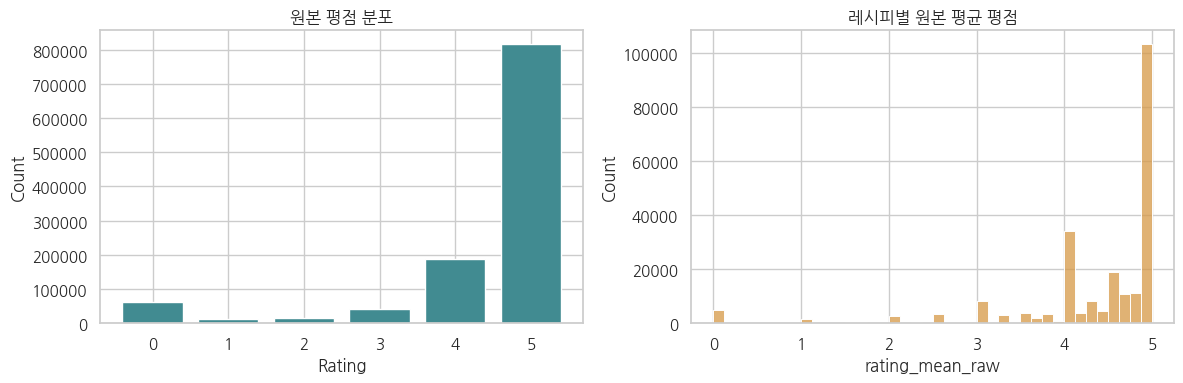

0점 비율: 5.37%


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rating_distribution = interactions_raw['rating'].value_counts().sort_index()
axes[0].bar(rating_distribution.index, rating_distribution.values, color='#418b91')
axes[0].set(title='원본 평점 분포', xlabel='Rating', ylabel='Count')
sns.histplot(recipes_eda['rating_mean_raw'], bins=40, ax=axes[1], color='#d69846')
axes[1].set_title('레시피별 원본 평균 평점')
fig.tight_layout()
save_figure(fig, '02_rating_distribution')
plt.show()
print(f"0점 비율: {interactions_raw['rating'].eq(0).mean():.2%}")

#### 로그변환 전후 왜도 비교표


In [19]:
log_cols = ['minutes'] + NUTRITION_COLS + ['rating_count_raw', 'review_count']
log_input = recipes_eda[log_cols].copy()
log_input['minutes'] = log_input['minutes'].mask(log_input['minutes'].ge(2**31 - 1))
log_input = log_input.mask(log_input.lt(0))
display(pd.DataFrame({
    'raw_skew': log_input.skew(), 'log1p_skew': np.log1p(log_input).skew()
}))

,raw_skew,log1p_skew
minutes,219.594778,0.494516
calories,215.302156,-0.437922
total_fat_pdv,55.748196,-0.469783
sugar_pdv,402.826416,0.032960
sodium_pdv,80.294591,-0.224615
protein_pdv,30.568763,-0.334209
saturated_fat_pdv,18.364630,-0.372344
carbohydrates_pdv,371.334540,0.068589
rating_count_raw,33.958067,1.702066
review_count,33.951208,1.701828


#### 로그변환 전후 분포 비교


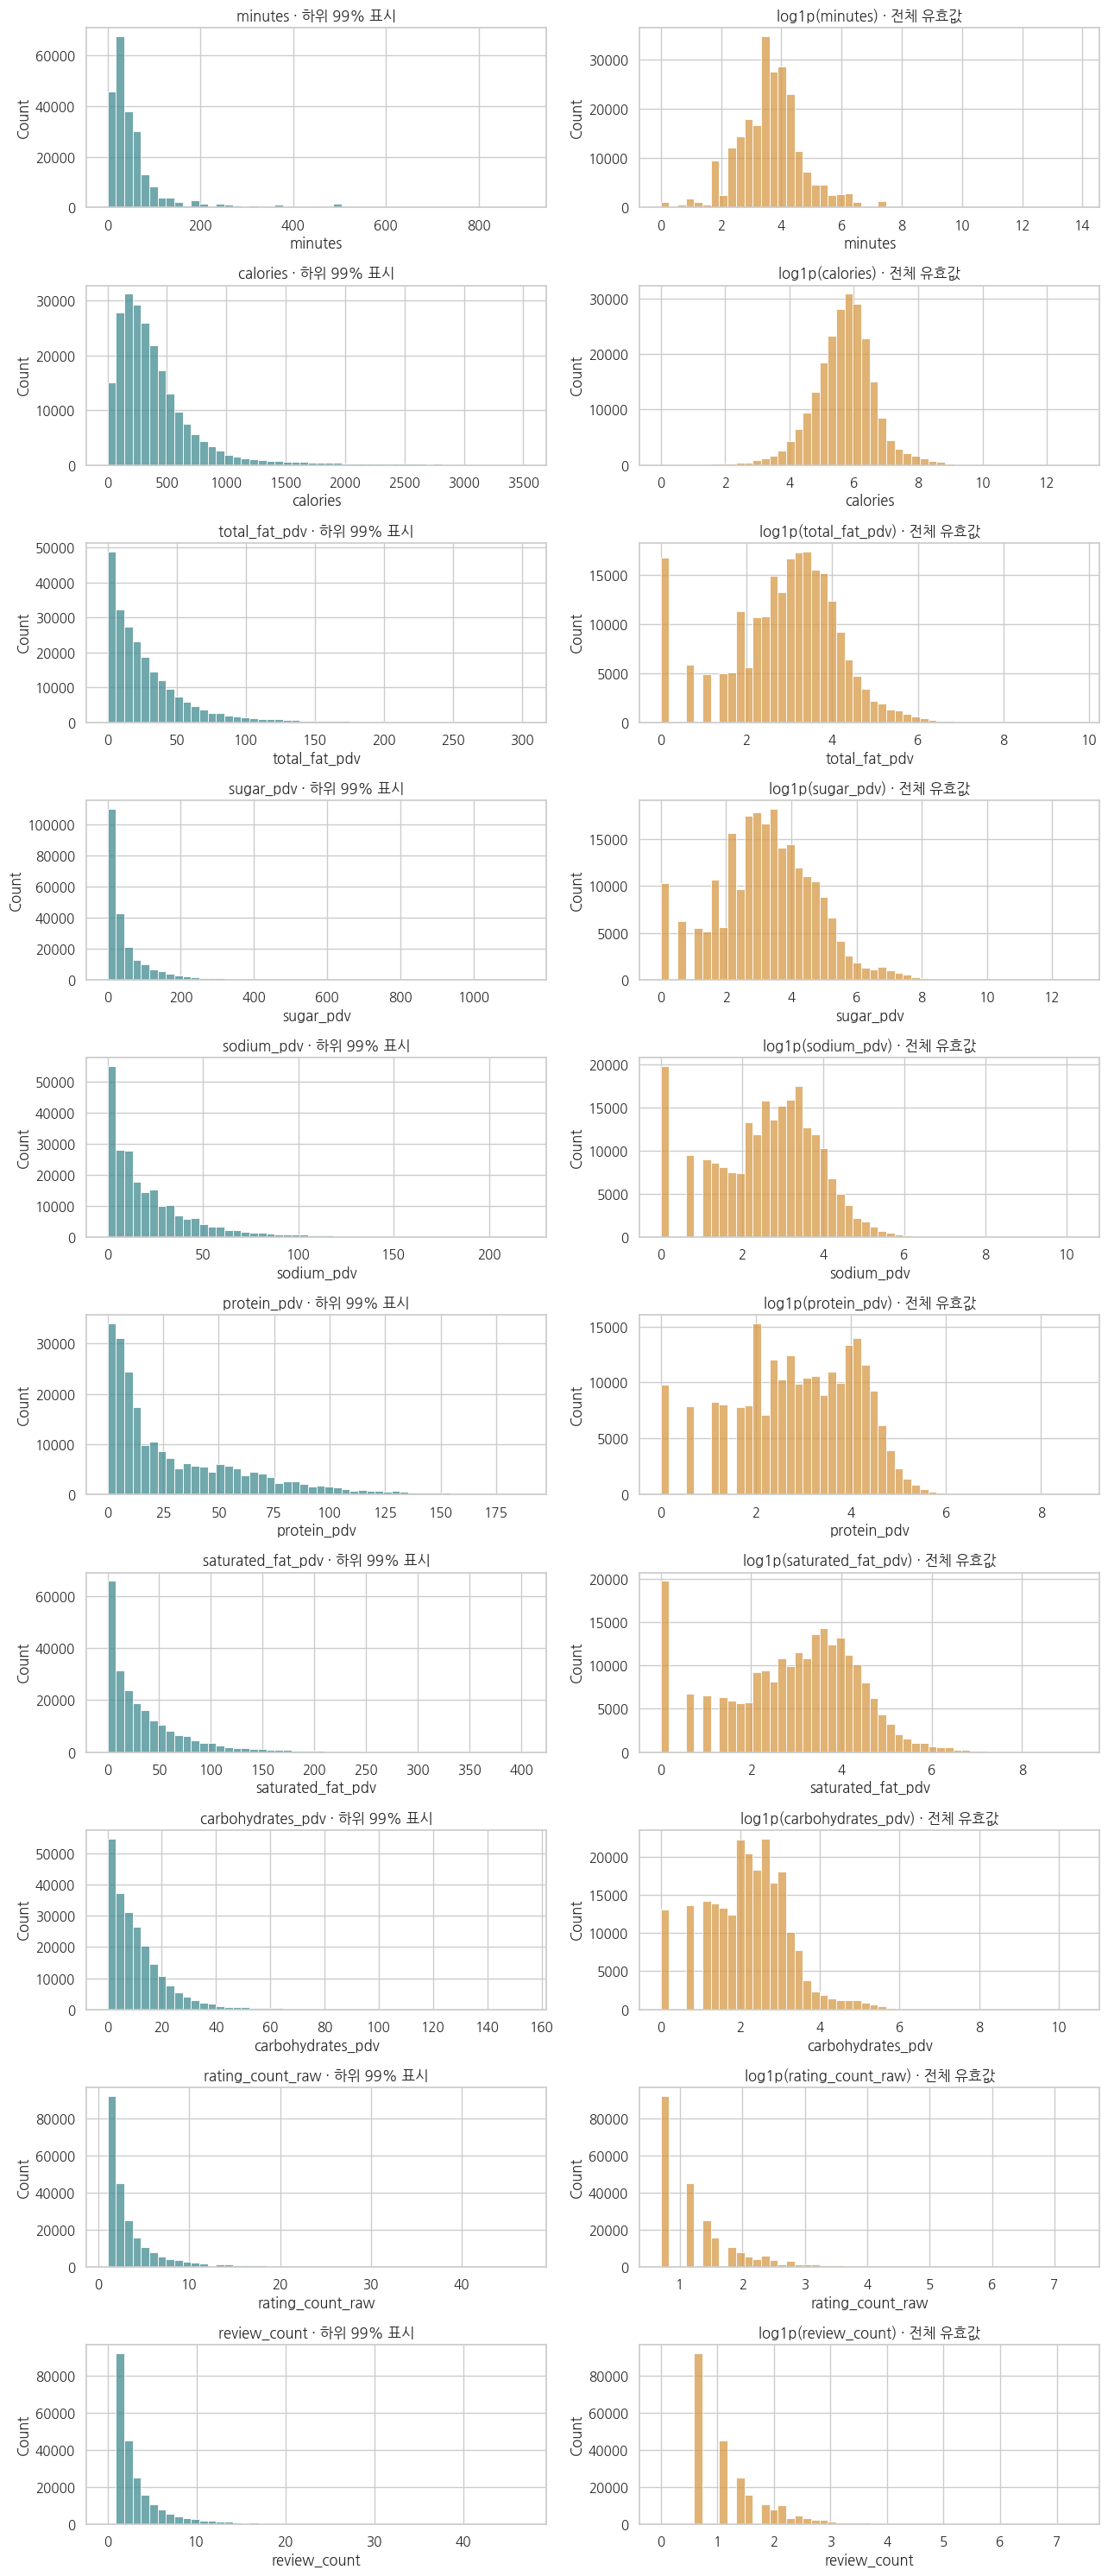

In [20]:
fig, axes = plt.subplots(len(log_cols), 2, figsize=(13, 3 * len(log_cols)))
for row, col in enumerate(log_cols):
    values = log_input[col].dropna()
    sns.histplot(values[values.le(values.quantile(.99))], bins=50, ax=axes[row, 0], color='#418b91')
    sns.histplot(np.log1p(values), bins=50, ax=axes[row, 1], color='#d69846')
    axes[row, 0].set_title(f'{col} · 하위 99% 표시')
    axes[row, 1].set_title(f'log1p({col}) · 전체 유효값')
fig.tight_layout()
save_figure(fig, '03_log_distributions')
plt.show()

### 1-4. 이상치와 0분 레시피 점검


#### 변수별 이상치 점검표


In [21]:
outlier_rows = []
for col in ['minutes', 'n_steps', 'n_ingredients'] + NUTRITION_COLS:
    values = recipes_parsed[col]
    q1, q3 = values.quantile([.25, .75])
    upper = q3 + 1.5 * (q3 - q1)
    outlier_rows.append({
        'variable': col, 'zero_count': values.eq(0).sum(),
        'negative_count': values.lt(0).sum(), 'iqr_upper': upper,
        'above_iqr_count': values.gt(upper).sum(), 'p99': values.quantile(.99), 'max': values.max()
    })
display(pd.DataFrame(outlier_rows))

,variable,zero_count,negative_count,iqr_upper,above_iqr_count,p99,max
0,minutes,1094,0,132.50,23714,903.920,2.147484e+09
1,n_steps,1,0,21.00,10018,30.000,1.450000e+02
2,n_ingredients,0,0,18.50,3770,20.000,4.300000e+01
3,calories,53,0,1037.65,15737,3516.956,4.343602e+05
4,total_fat_pdv,16770,0,90.50,16265,302.000,1.718300e+04
5,sugar_pdv,10322,0,156.50,23780,1141.640,3.627290e+05
6,sodium_pdv,19841,0,75.00,15919,219.000,2.933800e+04
7,protein_pdv,9837,0,117.00,9141,188.000,6.552000e+03
8,saturated_fat_pdv,19732,0,119.50,16462,404.000,1.039500e+04
9,carbohydrates_pdv,13068,0,34.00,15559,154.000,3.609800e+04


#### 이름이 없는 레시피


In [22]:
display(recipes_parsed.loc[recipes_parsed['name'].isna(), ['id', 'name', 'minutes', 'ingredients']])

,id,name,minutes,ingredients
721,368257,NaN,10,"['lemon', 'honey', 'horseradish mustard', 'garlic clove', 'dried parsley', 'dried basil', 'dried..."


#### 조리시간 상위 레시피


In [23]:
display(recipes_parsed.nlargest(5, 'minutes')[['id', 'name', 'minutes']])

,id,name,minutes
144074,261647,no bake granola balls,2147483647
109624,447963,how to preserve a husband,1051200
106563,291571,homemade fruit liquers,288000
38116,216215,celtic druid s honey mead meade metheglin,259260
106963,425681,homemade vanilla,259205


#### 0분 레시피의 단계 수와 가열 표현


In [24]:
COOKING_PATTERN = r'bake|boil|fry|cook|roast|saute|simmer|heat|preheat'
zero_minutes = recipes_parsed.loc[recipes_parsed['minutes'].eq(0)].copy()
zero_minutes['cooking_word'] = zero_minutes['steps'].str.contains(COOKING_PATTERN, case=False, na=False)
zero_minutes['step_group'] = pd.cut(
    zero_minutes['n_steps'], bins=[-1, 2, 4, 6, np.inf], labels=['0~2', '3~4', '5~6', '7+']
)
display(pd.crosstab(zero_minutes['step_group'], zero_minutes['cooking_word'], normalize='index').mul(100))

cooking_word,False,True
step_group,,
0~2,85.000000,15.000000
3~4,62.376238,37.623762
5~6,30.208333,69.791667
7+,6.438896,93.561104


#### 연도별 0분 레시피 수


In [25]:
display(zero_minutes.groupby(zero_minutes['submitted'].dt.year).size().rename('zero_minutes_count'))

,zero_minutes_count
submitted,
1999,737
2000,249
2001,21
2002,71
2003,13
2004,2
2008,1


### 1-5. 레시피 구성 Clustering : 재료 TF-IDF → SVD → KMeans
이름·재료가 있는 전체 레시피를 사용


#### 군집 입력 데이터 준비


In [26]:
recipes_base = recipes_parsed.dropna(subset=['name']).copy()
recipes_base['ingredients_norm'] = recipes_base['ingredients_list'].map(normalize_ingredients)
recipes_base['ingredients_set'] = recipes_base['ingredients_norm'].map(frozenset)
recipes_base['tags_list'] = recipes_base['tags_list'].map(
    lambda items: [x for x in items if isinstance(x, str) and x.strip()]
)
recipes_base = recipes_base.reset_index(drop=True)
recipes_base['base_position'] = np.arange(len(recipes_base))
cluster_input = recipes_base.loc[recipes_base['ingredients_norm'].str.len().gt(0)].copy().reset_index(drop=True)

#### 재료 TF-IDF와 SVD 변환


In [27]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
ingredient_vectorizer = TfidfVectorizer(
    tokenizer=str.split, token_pattern=None, lowercase=False, dtype=np.float32
)
ingredient_text = cluster_input['ingredients_norm'].map(
    lambda items: ' '.join(item.replace(' ', '_') for item in items)
)
X_ingredient_all = ingredient_vectorizer.fit_transform(ingredient_text)
if min(X_ingredient_all.shape) <= 2 or len(cluster_input) <= max(CLUSTER_K_VALUES):
    raise ValueError('군집 분석에 필요한 레시피·재료 수가 부족합니다.')
ingredient_svd = TruncatedSVD(n_components=min(100, min(X_ingredient_all.shape) - 1), random_state=SEED)
Z_ingredient = normalize(ingredient_svd.fit_transform(X_ingredient_all))
ingredient_terms = ingredient_vectorizer.get_feature_names_out()
print('TF-IDF:', X_ingredient_all.shape, 'SVD:', Z_ingredient.shape)
print(f'누적 설명 분산: {ingredient_svd.explained_variance_ratio_.sum():.1%}')

TF-IDF: (231636, 14929) SVD: (231636, 100)
누적 설명 분산: 26.0%


#### 군집 수별 모델 학습


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
cluster_sample_idx = np.random.default_rng(SEED).choice(len(cluster_input), min(3000, len(cluster_input)), replace=False)
cluster_models, cluster_score_rows = {}, []
for k in CLUSTER_K_VALUES:
    fitted = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Z_ingredient)
    labels = fitted.labels_
    sample_labels = labels[cluster_sample_idx]
    counts = np.bincount(labels, minlength=k)
    silhouette = np.nan
    if 1 < len(np.unique(sample_labels)) < len(sample_labels):
        silhouette = silhouette_score(Z_ingredient[cluster_sample_idx], sample_labels)
    cluster_models[k] = fitted
    cluster_score_rows.append({
        'k': k, 'silhouette': silhouette, 'inertia': fitted.inertia_,
        'min_cluster_size': counts.min(), 'max_cluster_share': counts.max() / counts.sum()
    })
cluster_scores = pd.DataFrame(cluster_score_rows)

#### 군집 수별 성능 비교표


In [29]:
display(cluster_scores)
cluster_scores.to_csv(OUTPUT_DIR / 'cluster_k_comparison.csv', index=False)

,k,silhouette,inertia,min_cluster_size,max_cluster_share
0,5,0.037470,196177.500000,26794,0.419602
1,6,0.041324,193566.046875,10269,0.420530


#### 군집 요약 함수


In [30]:
def summarize_clusters(k):
    fitted = cluster_models[k]
    frame = cluster_input.copy()
    frame['cluster'] = fitted.labels_
    frame['center_distance'] = np.linalg.norm(
        Z_ingredient - fitted.cluster_centers_[fitted.labels_], axis=1
    )
    rows = []
    for cluster in range(k):
        positions = np.flatnonzero(fitted.labels_ == cluster)
        if len(positions) == 0:
            continue
        mean_tfidf = np.asarray(X_ingredient_all[positions].mean(axis=0)).ravel()
        top_idx = np.argsort(mean_tfidf)[::-1][:5]
        examples = (frame.iloc[positions].sort_values(['center_distance', 'id'])
                    .drop_duplicates('name').head(3))
        rows.append({
            'cluster': cluster, 'recipe_count': len(positions),
            'share': len(positions) / len(frame),
            'top_ingredients': ', '.join(x.replace('_', ' ') for x in ingredient_terms[top_idx]),
            'representative_names': examples['name'].tolist(),
            'minutes_median': frame.iloc[positions]['minutes'].where(
                frame.iloc[positions]['minutes'].between(1, 2**31 - 2)
            ).median()
        })
    return frame, pd.DataFrame(rows).set_index('cluster')

#### 군집별 대표 재료·메뉴 비교표


In [31]:
cluster_frames, cluster_summaries = {}, {}
for k in CLUSTER_K_VALUES:
    cluster_frames[k], cluster_summaries[k] = summarize_clusters(k)
    print(f'k={k}')
    display(cluster_summaries[k])

k=5


,recipe_count,share,top_ingredients,representative_names,minutes_median
cluster,,,,,
0,30282,0.130731,"sugar, honey, orange juice, milk, cream cheese","[iced coffee ca phe vietnam, frozen amarula blush, papaya and strawberry coulis over pound cake]",15.0
1,97195,0.419602,"onion, salt, butter, pepper, garlic cloves","[cheesy orzo pilaf, shrimp cakes with a black bean and corn salsa, cubano hash]",40.0
2,31236,0.134850,"olive oil, garlic cloves, salt, onion, garlic","[easy yellow rice, pasta with brie, linguini with mushrooms and shrimp]",40.0
3,46129,0.199144,"egg, butter, sugar, baking powder, flour","[simple chocolate cupcakes, featherlight scones, banana bread with cashews pao de banana por...",45.0
4,26794,0.115673,"water, salt, sugar, onion, butter","[lebanese lamb meatball and rice soup, beef and broccoli crock pot, quick rice sandwich]",47.0


k=6


,recipe_count,share,top_ingredients,representative_names,minutes_median
cluster,,,,,
0,10269,0.044332,"banana, ice, orange juice, vodka, pineapple juice","[tropical champagne, dangerously red smoothie, r e d r u m cocktail]",5.0
1,27173,0.117309,"olive oil, garlic cloves, salt, onion, garlic","[riso verde green rice, easy yellow rice, pasta with brie]",40.0
2,55991,0.241720,"egg, sugar, butter, baking powder, salt","[simple chocolate cupcakes, best waffles ever, featherlight scones]",45.0
3,15277,0.065953,"salt and pepper, onion, olive oil, butter, garlic cloves","[andorran escudella, easy penne with chicken spinach and tomato alfredo soooo good, creamy ch...",40.0
4,97410,0.420530,"salt, onion, pepper, butter, garlic cloves","[ww smoky jalapeno burgers 8 pts, cheesy orzo pilaf, baked potatoes florentine]",35.0
5,25516,0.110156,"water, salt, sugar, onion, butter","[lebanese lamb meatball and rice soup, quick rice sandwich, beef and broccoli crock pot]",45.0


#### EDA 군집 선택과 저장


In [32]:
if CLUSTER_K not in cluster_models:
    raise ValueError(f'CLUSTER_K는 {CLUSTER_K_VALUES} 중에서 선택하세요.')
recipe_clusters = cluster_frames[CLUSTER_K][['id', 'cluster', 'center_distance']]
cluster_summary = cluster_summaries[CLUSTER_K]
recipe_clusters.to_csv(OUTPUT_DIR / 'recipe_clusters_eda.csv', index=False)

### 1-6. 레시피 구성 그래프

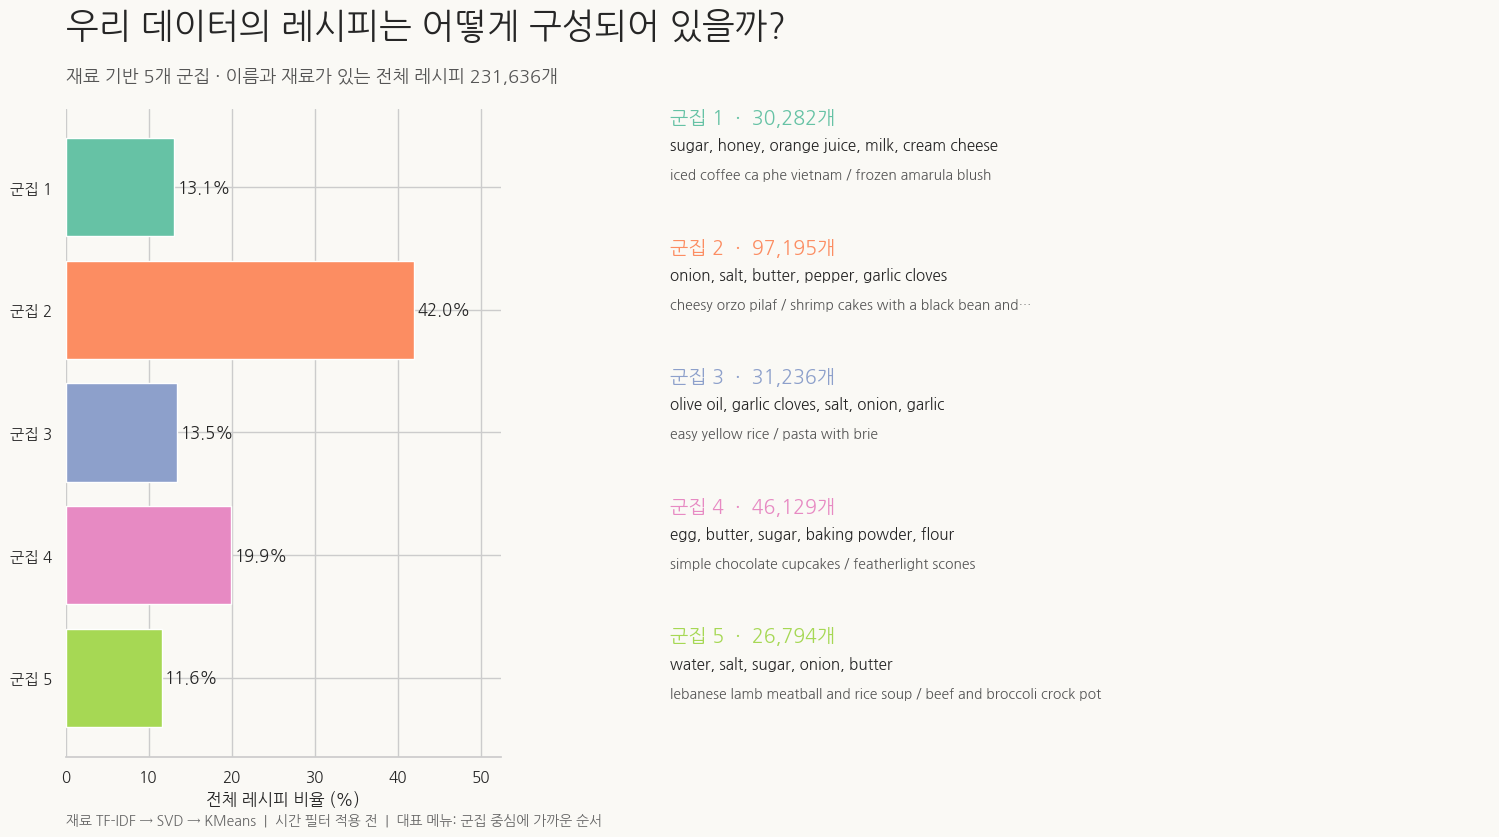

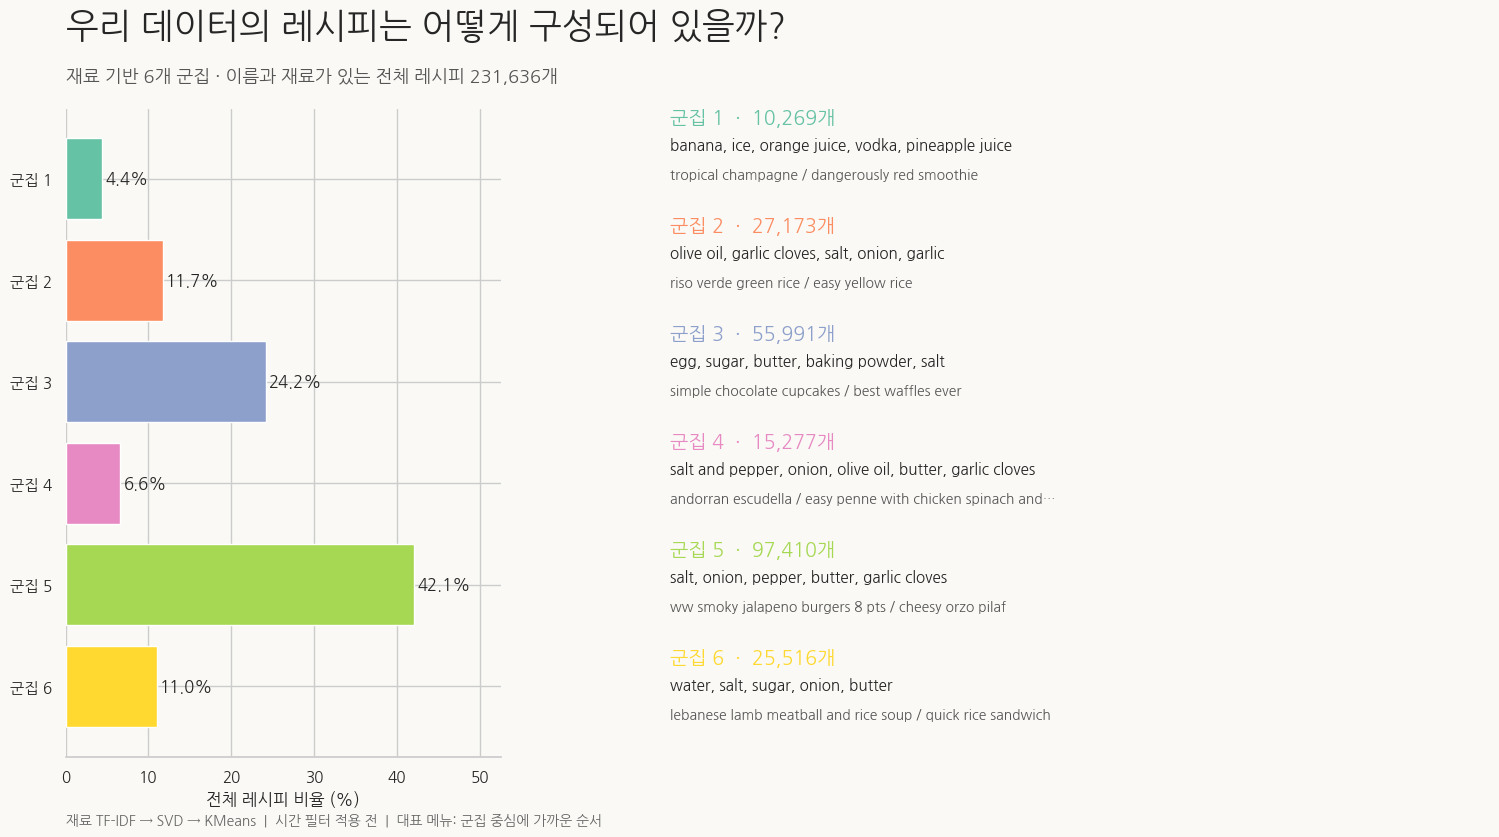

In [33]:
import textwrap
for k in CLUSTER_K_VALUES:
    summary = cluster_summaries[k]
    colors = sns.color_palette('Set2', k)
    fig = plt.figure(figsize=(16, 9), facecolor='#faf9f5')
    grid = fig.add_gridspec(1, 2, width_ratios=[.85, 1.6], left=.07, right=.96, top=.84, bottom=.12, wspace=.27)
    ax_bar = fig.add_subplot(grid[0, 0])
    ax_text = fig.add_subplot(grid[0, 1])
    labels = [CLUSTER_NAMES.get(int(c), f'군집 {c + 1}') if k == CLUSTER_K else f'군집 {c + 1}' for c in summary.index]
    bars = ax_bar.barh(labels, summary['share'] * 100, color=colors)
    ax_bar.invert_yaxis()
    ax_bar.set(xlabel='전체 레시피 비율 (%)', xlim=(0, max(summary['share']) * 125))
    ax_bar.set_facecolor('#faf9f5')
    for bar, row in zip(bars, summary.itertuples()):
        ax_bar.text(bar.get_width() + .4, bar.get_y() + bar.get_height() / 2,
                    f'{row.share:.1%}', va='center', fontsize=12)
    sns.despine(ax=ax_bar, left=True)
    ax_text.axis('off')
    for i, (cluster, row) in enumerate(summary.iterrows()):
        y = 1 - i / k
        examples = ' / '.join(textwrap.shorten(name, width=38, placeholder='…') for name in row['representative_names'][:2])
        heading = f"{labels[i]}  ·  {int(row['recipe_count']):,}개"
        ax_text.text(0, y, heading, fontsize=14, weight='bold', color=colors[i], va='top')
        ax_text.text(0, y - .045, textwrap.fill(row['top_ingredients'], width=70), fontsize=11, va='top')
        ax_text.text(0, y - .093, textwrap.fill(examples, width=76), fontsize=10, color='#555555', va='top')
    fig.text(.07, .92, '우리 데이터의 레시피는 어떻게 구성되어 있을까?', fontsize=25, weight='bold')
    fig.text(.07, .87, f'재료 기반 {k}개 군집 · 이름과 재료가 있는 전체 레시피 {len(cluster_input):,}개', fontsize=13, color='#555555')
    fig.text(.07, .045, '재료 TF-IDF → SVD → KMeans  |  시간 필터 적용 전  |  대표 메뉴: 군집 중심에 가까운 순서', fontsize=10, color='#666666')
    save_figure(fig, f'04_recipe_composition_k{k}')
    plt.show()

## 2️⃣ 전처리
### 2-1. 이름 결측과 조리시간 정제


#### 레시피 정제와 특징 생성


In [34]:
recipes = recipes_base.copy()
preprocessing_rows = [{'step': '원본', 'remaining': len(recipes_raw), 'removed': 0}]
preprocessing_rows.append({'step': '이름 결측 제거', 'remaining': len(recipes), 'removed': len(recipes_raw) - len(recipes)})
def remove_recipes(frame, mask, reason):
    removed = frame.loc[mask, ['id', 'name', 'minutes', 'submitted', 'n_steps']].copy()
    removed['reason'] = reason
    kept = frame.loc[~mask].copy()
    preprocessing_rows.append({'step': reason, 'remaining': len(kept), 'removed': len(removed)})
    return kept, removed

#### 시간 조건 적용


In [35]:
recipes, excluded_1999 = remove_recipes(
    recipes, recipes['minutes'].eq(0) & recipes['submitted'].dt.year.eq(1999), '1999년 0분'
)
recipes, excluded_time = remove_recipes(
    recipes, ~recipes['minutes'].between(0, MAX_MINUTES), '0~60분 범위 밖·시간 결측'
)
recipes, excluded_zero = remove_recipes(
    recipes,
    recipes['minutes'].eq(0) & (
        recipes['n_steps'].ge(5) | recipes['steps'].str.contains(COOKING_PATTERN, case=False, na=False)
    ), '0분 중 5단계 이상·가열 단어 포함'
)
recipes, excluded_empty = remove_recipes(
    recipes, recipes['ingredients_norm'].str.len().eq(0), '재료 목록 없음'
)

#### 로그변환과 핵심 재료


In [36]:
recipes = recipes.reset_index(drop=True)
for col in NUTRITION_COLS:
    recipes[col] = recipes[col].mask(recipes[col].lt(0))
for col in ['minutes'] + NUTRITION_COLS:
    recipes[f'log_{col}'] = np.log1p(recipes[col])
recipes['steps_text'] = recipes['steps_list'].map(lambda items: ' '.join(str(x) for x in items))
recipes['core_ingredients'] = recipes['ingredients_set'].map(lambda items: items - PANTRY_INGREDIENTS)
recipes['n_core_ingredients'] = recipes['core_ingredients'].map(len)
preprocessing_summary = pd.DataFrame(preprocessing_rows)

#### 단계별 정제 건수표


In [37]:
display(preprocessing_summary)
preprocessing_summary.to_csv(OUTPUT_DIR / 'recipe_filter_counts.csv', index=False, encoding='utf-8-sig')
pd.concat([excluded_1999, excluded_time, excluded_zero, excluded_empty]).to_csv(
    OUTPUT_DIR / 'excluded_recipes.csv', index=False, encoding='utf-8-sig'
)

,step,remaining,removed
0,원본,231637,0
1,이름 결측 제거,231636,1
2,1999년 0분,230899,737
3,0~60분 범위 밖·시간 결측,168392,62507
4,0분 중 5단계 이상·가열 단어 포함,168090,302
5,재료 목록 없음,168090,0


### 2-2. 0점 리뷰 감성분석


In [38]:
import hashlib
import json
zero_reviews = interactions_raw.loc[
    interactions_raw['rating'].eq(0) & interactions_raw['has_review'],
    ['interaction_id', 'recipe_id', 'user_id', 'rating', 'review']
].copy()
def sentiment_input_hash(row):
    value = json.dumps([int(row.interaction_id), int(row.recipe_id), int(row.user_id), row.review], ensure_ascii=False)
    return hashlib.sha256(value.encode('utf-8')).hexdigest()


In [39]:
zero_reviews['input_hash'] = [sentiment_input_hash(row) for row in zero_reviews.itertuples()]
RESULT_PATH = OUTPUT_DIR / 'zero_rating_sentiment_colab.csv'
MODEL_NAME = SENTIMENT_MODEL
MAX_LENGTH = 512
BATCH_SIZE = SENTIMENT_BATCH_SIZE


#### 저장된 결과 확인


In [40]:
prediction_cols = ['interaction_id', 'input_hash', 'sentiment', 'sentiment_confidence']
if RESULT_PATH.exists():
    previous = pd.read_csv(RESULT_PATH, encoding='utf-8-sig')
    if not previous['model_name'].eq(MODEL_NAME).all() or not previous['max_length'].eq(MAX_LENGTH).all():
        raise ValueError('기존 결과의 모델·입력 길이가 다릅니다. 결과 파일명을 바꾸세요.')
    if previous['interaction_id'].duplicated().any():
        raise ValueError('기존 결과 ID가 중복됩니다.')
    zero_sentiment = zero_reviews.merge(previous[prediction_cols], on=['interaction_id', 'input_hash'], how='left', validate='one_to_one')
else:
    zero_sentiment = zero_reviews.copy()
    zero_sentiment['sentiment'] = pd.Series(index=zero_sentiment.index, dtype='object')
    zero_sentiment['sentiment_confidence'] = np.nan
valid_done = zero_sentiment['sentiment'].isin(['negative', 'neutral', 'positive']) & zero_sentiment['sentiment_confidence'].between(0, 1)
pending = zero_sentiment.index[~valid_done].to_numpy()
print('남은 리뷰:', len(pending))


남은 리뷰: 23471


#### 모델 로딩


In [41]:
if len(pending):
    from huggingface_hub import hf_hub_download
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
    print('모델 다운로드', flush=True)
    hf_hub_download(repo_id=MODEL_NAME, filename='pytorch_model.bin')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print('모델 로딩', flush=True)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, use_safetensors=False)
    sentiment_pipeline = pipeline('sentiment-analysis', model=model, tokenizer=tokenizer, device=SENTIMENT_DEVICE)
    print('사용 장치:', sentiment_pipeline.device, flush=True)


모델 다운로드


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


사용 장치: cuda:0


#### 감성분석 실행 · 512건마다 저장


In [42]:
def save_results():
    valid = zero_sentiment['sentiment'].isin(['negative', 'neutral', 'positive']) & zero_sentiment['sentiment_confidence'].between(0, 1)
    output = zero_sentiment.loc[valid].copy()
    output['model_name'] = MODEL_NAME
    output['max_length'] = MAX_LENGTH
    temporary = RESULT_PATH.with_suffix('.tmp')
    output.to_csv(temporary, index=False, encoding='utf-8-sig')
    temporary.replace(RESULT_PATH)


In [43]:
label_map = {'label_0': 'negative', 'label_1': 'neutral', 'label_2': 'positive'}
with tqdm(total=len(pending), desc='0점 리뷰', unit='건') as progress:
    for start in range(0, len(pending), 512):
        chunk = pending[start:start + 512]
        for batch_start in range(0, len(chunk), BATCH_SIZE):
            idx = chunk[batch_start:batch_start + BATCH_SIZE]
            predictions = sentiment_pipeline(zero_sentiment.loc[idx, 'review'].astype(str).tolist(),
                                            batch_size=BATCH_SIZE, truncation=True, max_length=MAX_LENGTH)
            labels = [label_map.get(item['label'].lower(), item['label'].lower()) for item in predictions]
            if not set(labels).issubset({'negative', 'neutral', 'positive'}):
                raise ValueError(f'감성 라벨 확인 필요: {set(labels)}')
            zero_sentiment.loc[idx, 'sentiment'] = labels
            zero_sentiment.loc[idx, 'sentiment_confidence'] = [item['score'] for item in predictions]
            progress.update(len(idx))
        save_results()
save_results()

0점 리뷰:   0%|          | 0/23471 [00:00<?, ?건/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [44]:
valid_done = zero_sentiment['sentiment'].isin(['negative', 'neutral', 'positive']) & zero_sentiment['sentiment_confidence'].between(0, 1)
assert valid_done.all(), '완료되지 않은 리뷰가 있습니다.'
display(zero_sentiment['sentiment'].value_counts())
print('저장 위치:', RESULT_PATH)

,count
sentiment,
positive,40426
neutral,10641
negative,9780


저장 위치: /content/drive/MyDrive/DartB_Dana/outputs/final_analysis/zero_rating_sentiment_colab.csv


In [46]:
import gc
for variable in ['sentiment_pipeline', 'model', 'tokenizer']:
    globals().pop(variable, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

#### 긍정·중립 0점 리뷰 제외


In [47]:
noise_interaction_ids = zero_sentiment.loc[
    zero_sentiment['sentiment'].isin(['positive', 'neutral']), 'interaction_id'
]
interactions_clean = interactions_raw.loc[~interactions_raw['interaction_id'].isin(noise_interaction_ids)].copy()
interactions = interactions_clean.loc[interactions_clean['recipe_id'].isin(recipes['id'])].copy()
print('감성분석한 0점 리뷰:', len(zero_sentiment))
print('긍정·중립 0점 제거:', len(noise_interaction_ids))
print('추천 대상 레시피의 정제 리뷰:', len(interactions))
zero_sentiment.to_csv(OUTPUT_DIR / 'zero_rating_sentiment.csv', index=False, encoding='utf-8-sig')

감성분석한 0점 리뷰: 60847
긍정·중립 0점 제거: 51067
추천 대상 레시피의 정제 리뷰: 772005


### 2-3. 베이지안 평점
C는 레시피별 평균 평점의 평균, m은 평가 수 중앙값.
평가 수는 정제 후 기준이며, 등록 수와 텍스트 리뷰 수는 원본 기준


#### 베이지안 평점 계산과 결합


In [48]:
rating_stats = interactions.groupby('recipe_id')['rating'].agg(rating_mean='mean', rating_count='count')
if rating_stats.empty:
    raise ValueError('전처리 후 평점 데이터가 없습니다.')
prior_mean = float(rating_stats['rating_mean'].mean())
prior_strength = float(rating_stats['rating_count'].quantile(BAYES_PRIOR_QUANTILE))
rating_stats['bayesian_rating'] = (
    rating_stats['rating_count'] * rating_stats['rating_mean'] + prior_strength * prior_mean
) / (rating_stats['rating_count'] + prior_strength)
rating_stats = rating_stats.rename_axis('id').reset_index()
rating_stats.to_csv(OUTPUT_DIR / 'recipe_bayesian_ratings.csv', index=False, encoding='utf-8-sig')

#### 평점 CSV 병합


In [49]:
rating_csv = pd.read_csv(OUTPUT_DIR / 'recipe_bayesian_ratings.csv', encoding='utf-8-sig')
recipes = recipes.merge(rating_csv, on='id', how='left', validate='one_to_one')
recipes['rating_count'] = recipes['rating_count'].fillna(0).astype(int)
recipes['bayesian_rating'] = recipes['bayesian_rating'].fillna(prior_mean)
recipes = recipes.merge(
    raw_rating_stats[['id', 'interaction_count', 'review_count']], on='id', how='left', validate='one_to_one'
)
for col in ['rating_count', 'interaction_count', 'review_count']:
    recipes[col] = recipes[col].fillna(0).astype(int)
    recipes[f'log_{col}'] = np.log1p(recipes[col])

#### 보정 평점 기술통계표


In [50]:
print(f'C={prior_mean:.4f}, m={prior_strength:.2f}')
display(recipes[['rating_mean', 'rating_count', 'bayesian_rating']].describe())

C=4.5406, m=2.00


,rating_mean,rating_count,bayesian_rating
count,165537.000000,168090.000000,168090.000000
mean,4.540565,4.592807,4.554893
std,0.721282,14.828114,0.316221
min,0.000000,0.000000,1.513522
25%,4.250000,1.000000,4.360376
50%,4.857143,2.000000,4.693710
75%,5.000000,4.000000,4.770282
max,5.000000,1360.000000,4.995264


### 2-4. 음식 분류·군집 병합과 전처리 저장


#### 분류 메타데이터 결합과 저장


In [51]:
metadata = pd.read_csv(DATA_DIR / 'recipe_metadata_final.csv', encoding='utf-8-sig', usecols=['id'] + CATEGORY_COLS)
assert metadata['id'].is_unique
for col in CATEGORY_COLS:
    metadata[col] = metadata[col].map(parse_list)
recipes = recipes.merge(metadata, on='id', how='left', validate='one_to_one', indicator='metadata_merge')
print('음식 분류 미매칭:', recipes['metadata_merge'].ne('both').sum())
for col in CATEGORY_COLS:
    recipes[col] = recipes[col].map(parse_list)
eda_clusters = recipe_clusters.rename(columns={'cluster': 'eda_cluster', 'center_distance': 'eda_center_distance'})
recipes = recipes.drop(columns='metadata_merge').merge(eda_clusters, on='id', how='left', validate='one_to_one')
assert recipes['eda_cluster'].notna().all()
recipes['eda_cluster'] = recipes['eda_cluster'].astype(int)
recipes = recipes.reset_index(drop=True)

음식 분류 미매칭: 0


#### 저장 함수


In [52]:
def export_recipes(frame, path):
    result = frame.copy()
    for col in result.columns:
        if result[col].map(lambda value: isinstance(value, (list, tuple, set, frozenset))).any():
            result[col] = result[col].map(
                lambda value: json.dumps(sorted(value) if isinstance(value, (set, frozenset)) else list(value), ensure_ascii=False)
                if isinstance(value, (list, tuple, set, frozenset)) else value
            )
    result.to_csv(path, index=False, encoding='utf-8-sig')

#### 전처리 저장


In [53]:
assert recipes['id'].is_unique
assert recipes['minutes'].between(0, MAX_MINUTES).all()
assert recipes['bayesian_rating'].between(0, 5).all()
assert not interactions['interaction_id'].isin(noise_interaction_ids).any()
export_recipes(recipes, OUTPUT_DIR / 'recipes_preprocessed_final.csv')

#### 최종 전처리 데이터 미리보기


In [54]:
display(recipes[['id', 'name', 'minutes', 'rating_count', 'bayesian_rating', 'eda_cluster']].head())

,id,name,minutes,rating_count,bayesian_rating,eda_cluster
0,137739,arriba baked winter squash mexican style,55,3,4.816226,1
1,31490,a bit different breakfast pizza,30,3,4.616226,3
2,59389,alouette potatoes,45,2,4.520282,1
3,25274,aww marinated olives,15,1,3.693710,4
4,109439,berry good sandwich spread,5,1,4.027043,4


## 3️⃣ 가설검정
### 3-1. 보유 재료 수에 따른 한계 효용 차이
기본 양념 10종을 보유했다고 가정. 상위 50개 재료에서 무작위 보유·추가 구매를 100회씩 모의실험한다.


#### 한계 효용 검정 함수와 시뮬레이션


In [55]:
from collections import Counter
from scipy import stats
def kruskal_result(groups):
    groups = [np.asarray(group, dtype=float) for group in groups]
    groups = [group[np.isfinite(group)] for group in groups]
    groups = [group for group in groups if len(group)]
    n, k = sum(map(len, groups)), len(groups)
    if k < 2 or n <= k:
        return {'H': np.nan, 'p_value': np.nan, 'epsilon_squared': np.nan, 'n': n, 'groups': k}
    if np.unique(np.concatenate(groups)).size == 1:
        h, p = 0.0, 1.0
    else:
        h, p = stats.kruskal(*groups)
    return {'H': h, 'p_value': p, 'epsilon_squared': max(0.0, (h - k + 1) / (n - k)), 'n': n, 'groups': k}

#### 보유 재료 수 설정


In [56]:
core_sets = recipes['core_ingredients'].tolist()
core_frequency = Counter(ingredient for items in core_sets for ingredient in items)
ingredient_pool = [ingredient for ingredient, _ in sorted(core_frequency.items(), key=lambda item: (-item[1], item[0]))[:50]]
inventory_sizes = sorted(set(int(recipes['n_core_ingredients'].quantile(q)) for q in [.25, .5, .75]))
if any(k >= len(ingredient_pool) for k in inventory_sizes):
    raise ValueError('보유 재료 수가 구매 후보 재료 수보다 큽니다.')

#### 재료 추가 모의실험


In [57]:
rng = np.random.default_rng(SEED)
simulation_rows = []
for k in inventory_sizes:
    eligible_sets = [items for items in core_sets if len(items) <= k + 1]
    for trial in range(100):
        owned = frozenset(rng.choice(ingredient_pool, size=k, replace=False))
        purchase = rng.choice([item for item in ingredient_pool if item not in owned])
        expanded = owned | {purchase}
        before = sum(items.issubset(owned) for items in eligible_sets)
        after = sum(items.issubset(expanded) for items in eligible_sets)
        simulation_rows.append({'inventory_size': k, 'trial': trial, 'purchase': purchase, 'delta_n': after - before})
marginal_simulation = pd.DataFrame(simulation_rows)

#### 집단별 요약과 검정


In [58]:
marginal_summary = marginal_simulation.groupby('inventory_size')['delta_n'].agg(
    count='count', mean='mean', median='median', std='std',
    positive_gain_rate=lambda values: values.gt(0).mean()
)
marginal_test = pd.DataFrame([kruskal_result([
    group['delta_n'] for _, group in marginal_simulation.groupby('inventory_size')
])])

#### 보유 재료 수별 증가폭 요약표


In [59]:
display(marginal_summary)

,count,mean,median,std,positive_gain_rate
inventory_size,,,,,
5,100,6.11,2.0,12.036892,0.73
7,100,5.28,3.0,11.017965,0.77
9,100,7.45,2.0,25.934017,0.76


#### 집단 차이 검정 결과


In [60]:
display(marginal_test)
print('귀무가설: 보유 재료 수 집단 간 신규 레시피 증가폭 분포에 차이가 없다.')
print('결론:', '귀무가설 기각' if marginal_test['p_value'].iloc[0] < .05 else '귀무가설을 기각할 근거 부족 또는 검정 불가')
marginal_simulation.to_csv(OUTPUT_DIR / 'hypothesis1_simulations.csv', index=False)
marginal_test.to_csv(OUTPUT_DIR / 'hypothesis1_test.csv', index=False)

,H,p_value,epsilon_squared,n,groups
0,0.076818,0.962319,0.0,300,3


귀무가설: 보유 재료 수 집단 간 신규 레시피 증가폭 분포에 차이가 없다.
결론: 귀무가설을 기각할 근거 부족 또는 검정 불가


#### 보유 재료 수별 증가폭 시각화


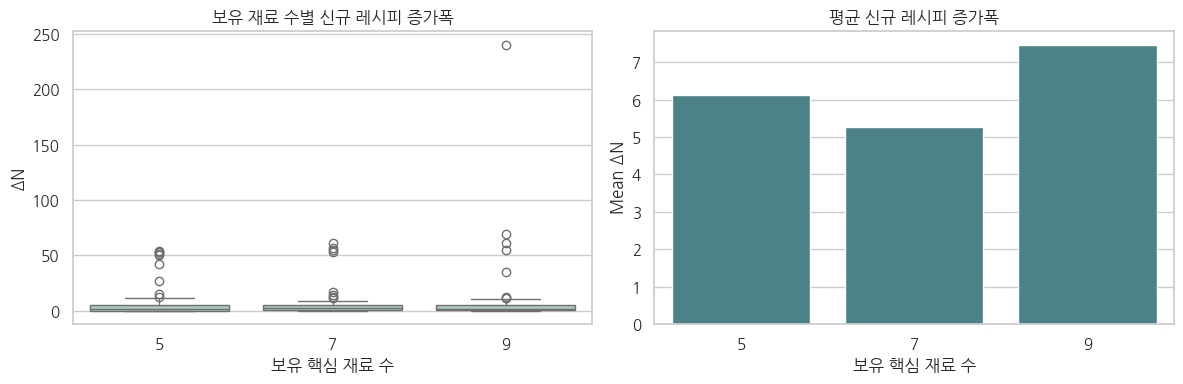

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=marginal_simulation, x='inventory_size', y='delta_n', ax=axes[0], color='#a5cec8')
sns.barplot(data=marginal_simulation, x='inventory_size', y='delta_n', estimator='mean', errorbar=None, ax=axes[1], color='#418b91')
axes[0].set(title='보유 재료 수별 신규 레시피 증가폭', xlabel='보유 핵심 재료 수', ylabel='ΔN')
axes[1].set(title='평균 신규 레시피 증가폭', xlabel='보유 핵심 재료 수', ylabel='Mean ΔN')
fig.tight_layout()
save_figure(fig, '05_marginal_gain')
plt.show()

### 3-2. 0점 평점은 부정적 평가인가: 리뷰 길이·의도·감성
제거 전 원본 리뷰를 사용합니다. 길이 차이 검정과 감성 예측을 함께 확인합니다.


#### 평점 그룹별 리뷰 길이 요약표


In [62]:
review_analysis = interactions_raw[['interaction_id', 'rating', 'review', 'has_review']].copy()
review_analysis['word_count'] = review_analysis['review'].fillna('').str.split().str.len()
review_analysis['char_count'] = review_analysis['review'].fillna('').str.len()
review_analysis['rating_group'] = np.where(review_analysis['rating'].eq(0), '0점', '1~5점')
display(review_analysis.groupby('rating_group')[['word_count', 'char_count']].agg(['count', 'mean', 'median']))

word_count                   char_count                   
                  count       mean median      count        mean median
rating_group                                                           
0점                60847  46.794074   37.0      60847  250.648315  195.0
1~5점            1071520  52.310909   45.0    1071520  279.942008  239.0

#### 리뷰 길이 차이 검정


In [63]:
length_test_rows = []
for scope, frame in [('전체 리뷰', review_analysis), ('텍스트 있는 리뷰', review_analysis.loc[review_analysis['has_review']])]:
    zero = frame.loc[frame['rating'].eq(0), 'word_count']
    nonzero = frame.loc[frame['rating'].gt(0), 'word_count']
    if len(zero) and len(nonzero):
        u, p = stats.mannwhitneyu(zero, nonzero, alternative='two-sided', method='asymptotic')
        length_test_rows.append({
            'scope': scope, 'n_zero': len(zero), 'n_nonzero': len(nonzero), 'U': u, 'p_value': p,
            'rank_biserial_zero_minus_nonzero': 2 * u / (len(zero) * len(nonzero)) - 1
        })
length_tests = pd.DataFrame(length_test_rows)
display(length_tests)
length_tests.to_csv(OUTPUT_DIR / 'hypothesis2_length_tests.csv', index=False, encoding='utf-8-sig')

,scope,n_zero,n_nonzero,U,p_value,rank_biserial_zero_minus_nonzero
0,전체 리뷰,60847,1071520,2.800047e+10,0.0,-0.141074
1,텍스트 있는 리뷰,60847,1071348,2.799000e+10,0.0,-0.141257


#### 0점 리뷰의 키워드 의도 요약표


In [64]:
zero_intents = review_analysis.loc[review_analysis['rating'].eq(0)].copy()
text = zero_intents['review'].fillna('').str.lower()
fail_pattern = r"\b(?:terrible|horrible|awful|waste|ruined|bland|disaster|gross|disgusting|dry|threw|inedible|did not work|didn't work|bad|worst)\b"
save_pattern = r"\b(?:haven't made|havent made|haven't tried|cant wait|cannot wait|sounds good|sounds delicious|looks good|saving|bookmark|will try|plan to make|want to try|haven't cooked)\b"
inquiry_pattern = r'\b(?:question|can i|could i|how much|substitute|replace|instead of)\b|\?'
zero_intents['intent'] = np.select(
    [text.str.contains(fail_pattern), text.str.contains(save_pattern), text.str.contains(inquiry_pattern)],
    ['실패·불만 표현', '저장·기대 표현', '질문·대체 문의 표현'], default='기타·판별 불가'
)
intent_summary = zero_intents['intent'].value_counts().rename('count').to_frame()
intent_summary['pct'] = intent_summary['count'] / len(zero_intents) * 100 if len(zero_intents) else np.nan
display(intent_summary)

,count,pct
intent,,
기타·판별 불가,44176,72.601772
질문·대체 문의 표현,9877,16.232518
실패·불만 표현,4639,7.624041
저장·기대 표현,2155,3.541670


#### 0점 리뷰의 감성 요약표


In [65]:
sentiment_summary = zero_sentiment['sentiment'].value_counts().reindex(['negative', 'neutral', 'positive'], fill_value=0).rename('count').to_frame()
sentiment_summary['pct_of_text_zero'] = sentiment_summary['count'] / len(zero_sentiment) * 100 if len(zero_sentiment) else np.nan
display(sentiment_summary)
print('텍스트 없는 0점:', (interactions_raw['rating'].eq(0) & ~interactions_raw['has_review']).sum())

,count,pct_of_text_zero
sentiment,,
negative,9780,16.073101
neutral,10641,17.488126
positive,40426,66.438773


텍스트 없는 0점: 0


#### 의도·감성 교차표


In [66]:
if len(zero_sentiment):
    display(pd.crosstab(zero_intents.set_index('interaction_id')['intent'], zero_sentiment.set_index('interaction_id')['sentiment']))

sentiment,negative,neutral,positive
intent,,,
기타·판별 불가,5159,6081,32936
실패·불만 표현,2578,579,1482
저장·기대 표현,357,442,1356
질문·대체 문의 표현,1686,3539,4652


#### 감성별 리뷰 예시


In [67]:
if len(zero_sentiment):
    display(zero_sentiment.groupby('sentiment', group_keys=False).head(3)[['rating', 'review', 'sentiment', 'sentiment_confidence']])

,rating,review,sentiment,sentiment_confidence
0,0,"Just an observation, so I will not rate. I followed this procedure with strawberries instead of...",neutral,0.488162
1,0,Made my own buttermilk w/ vinegar and milk. Used defrosted fresh skinless/boneless chicken fill...,positive,0.875479
2,0,This is a very good recipe. We also want to cut back on the fat content in our diet . Very tast...,positive,0.975692
3,0,i made it and it was amazing,positive,0.986328
7,0,Do you have cook the potatoes beforehand?,neutral,0.939401
10,0,"Just posting, so I will know I tryed this. Never have found one of his recipes that I like. Did ...",negative,0.631811
12,0,To everyone reading this. There is no such thing as St Louis Gooey Buttercake. Buttercake or Phi...,neutral,0.782383
25,0,These did not turn out very well for me..they were so soft that I couldn't get them out of the p...,negative,0.424786
27,0,"Oh, forgot to add, NO FLOUR in this recipe???",negative,0.768890


#### 0점 리뷰 의도와 감성 분포


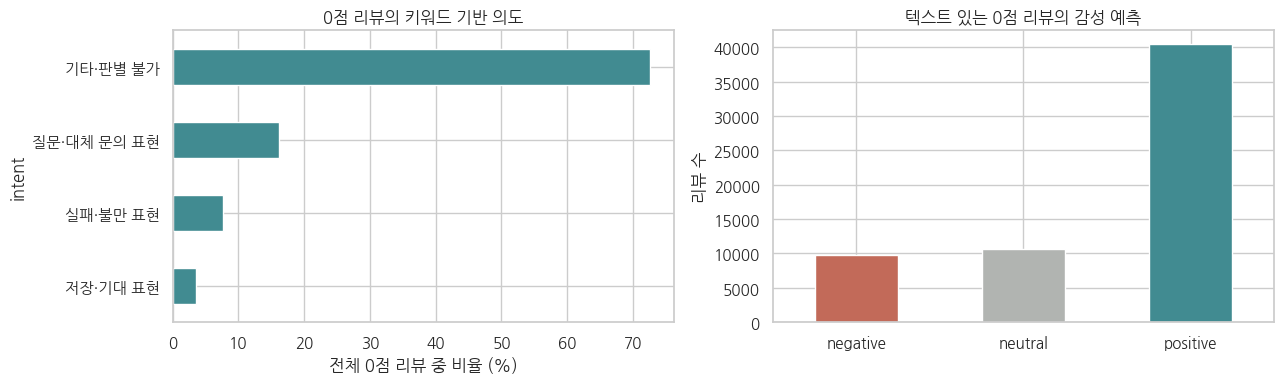

기타 표현은 긍정·중립을 뜻하지 않으며, 감성 예측도 실제 평가 의도를 확정하지 않습니다.


In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
intent_summary['pct'].sort_values().plot.barh(ax=axes[0], color='#418b91')
sentiment_summary['count'].plot.bar(ax=axes[1], color=['#c26a59', '#b1b4b1', '#418b91'], rot=0)
axes[0].set(title='0점 리뷰의 키워드 기반 의도', xlabel='전체 0점 리뷰 중 비율 (%)')
axes[1].set(title='텍스트 있는 0점 리뷰의 감성 예측', xlabel='', ylabel='리뷰 수')
fig.tight_layout()
save_figure(fig, '06_zero_rating_review')
plt.show()
sentiment_summary.to_csv(OUTPUT_DIR / 'hypothesis2_sentiment_summary.csv')
print('기타 표현은 긍정·중립을 뜻하지 않으며, 감성 예측도 실제 평가 의도를 확정하지 않습니다.')

### 3-3. 영양성분과 인기도·만족도
검정용 데이터에만 영양성분 상위 1% 클리핑을 적용한다.


#### 영양성분 상관분석


In [69]:
nutrition_analysis = recipes[NUTRITION_COLS + ['rating_mean', 'interaction_count']].copy()
for col in NUTRITION_COLS:
    nutrition_analysis[col] = nutrition_analysis[col].clip(upper=nutrition_analysis[col].quantile(.99))

#### 다중검정 보정 함수


In [70]:
def benjamini_hochberg(p_values):
    values = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(values), np.nan)
    valid_idx = np.flatnonzero(np.isfinite(values))
    order = valid_idx[np.argsort(values[valid_idx])]
    if len(order):
        ranked = values[order] * len(order) / np.arange(1, len(order) + 1)
        adjusted[order] = np.minimum.accumulate(ranked[::-1])[::-1].clip(0, 1)
    return adjusted

#### 영양성분별 상관계수 계산


In [71]:
correlation_rows = []
for nutrient in NUTRITION_COLS:
    for target in ['rating_mean', 'interaction_count']:
        pair = nutrition_analysis[[nutrient, target]].dropna()
        rho, p = (np.nan, np.nan)
        if len(pair) >= 3 and pair.nunique().min() > 1:
            rho, p = stats.spearmanr(pair[nutrient], pair[target])
        correlation_rows.append({'nutrient': nutrient, 'target': target, 'n': len(pair), 'rho': rho, 'p_value': p})
nutrition_correlations = pd.DataFrame(correlation_rows)
nutrition_correlations['p_fdr'] = benjamini_hochberg(nutrition_correlations['p_value'])

#### 영양성분과 평점·인기도 상관계수표


In [72]:
display(nutrition_correlations)
nutrition_correlations.to_csv(OUTPUT_DIR / 'hypothesis3_correlations.csv', index=False)

,nutrient,target,n,rho,p_value,p_fdr
0,calories,rating_mean,165537,-0.001393,5.707440e-01,5.707440e-01
1,calories,interaction_count,168090,-0.018494,3.375617e-14,1.181466e-13
2,total_fat_pdv,rating_mean,165537,0.016757,9.212005e-12,2.149468e-11
3,total_fat_pdv,interaction_count,168090,-0.014026,8.883088e-09,1.554540e-08
4,sugar_pdv,rating_mean,165537,0.023794,3.586686e-22,2.510680e-21
5,sugar_pdv,interaction_count,168090,-0.014376,3.767569e-09,7.535137e-09
6,sodium_pdv,rating_mean,165537,-0.023089,5.704298e-21,2.662006e-20
7,sodium_pdv,interaction_count,168090,0.012883,1.278111e-07,1.626687e-07
8,protein_pdv,rating_mean,165537,-0.038440,3.562702e-55,4.987783e-54
9,protein_pdv,interaction_count,168090,-0.007216,3.089713e-03,3.604665e-03


#### 영양 그룹 구성과 차이 검정


In [73]:
cal_low, cal_high = nutrition_analysis['calories'].quantile([.33, .66])
protein_high = nutrition_analysis['protein_pdv'].quantile(.66)
fat_high = nutrition_analysis['total_fat_pdv'].quantile(.66)
nutrition_analysis['nutrition_group'] = np.select(
    [nutrition_analysis['calories'].le(cal_low),
     nutrition_analysis['protein_pdv'].ge(protein_high) & nutrition_analysis['calories'].le(cal_high),
     nutrition_analysis['calories'].gt(cal_high) & nutrition_analysis['total_fat_pdv'].ge(fat_high)],
    ['Light / Low-Cal', 'High-Protein', 'Heavy / Indulgent'], default='Standard'
)
valid_profile = nutrition_analysis[['calories', 'protein_pdv', 'total_fat_pdv']].notna().all(axis=1)
nutrition_analysis.loc[~valid_profile, 'nutrition_group'] = pd.NA
nutrition_group_tests = []
for target in ['rating_mean', 'interaction_count']:
    result = kruskal_result([group[target] for _, group in nutrition_analysis.dropna(subset=['nutrition_group']).groupby('nutrition_group')])
    nutrition_group_tests.append({'target': target, **result})
nutrition_group_tests = pd.DataFrame(nutrition_group_tests)
nutrition_group_tests['p_fdr'] = benjamini_hochberg(nutrition_group_tests['p_value'])

#### 영양 그룹별 검정 결과표


In [74]:
display(nutrition_group_tests)

,target,H,p_value,epsilon_squared,n,groups,p_fdr
0,rating_mean,70.867958,2.782191e-15,0.000410,165537,4,5.564382e-15
1,interaction_count,54.450304,8.994437e-12,0.000306,168090,4,8.994437e-12


#### 영양 그룹별 기술통계표


In [75]:
display(nutrition_analysis.groupby('nutrition_group')[['rating_mean', 'interaction_count']].agg(['count', 'mean', 'median']))
nutrition_group_tests.to_csv(OUTPUT_DIR / 'hypothesis3_group_tests.csv', index=False)

rating_mean                     interaction_count            \
                        count      mean    median             count      mean   
nutrition_group                                                                 
Heavy / Indulgent       44887  4.549631  4.888889             45662  4.700911   
High-Protein            17218  4.534881  4.777778             17432  5.157354   
Light / Low-Cal         54656  4.534787  4.869048             55486  4.797138   
Standard                48776  4.540702  4.875000             49510  4.752575   

                          
                  median  
nutrition_group           
Heavy / Indulgent    2.0  
High-Protein         2.0  
Light / Low-Cal      2.0  
Standard             2.0

#### 영양성분과 평점·인기도 상관관계

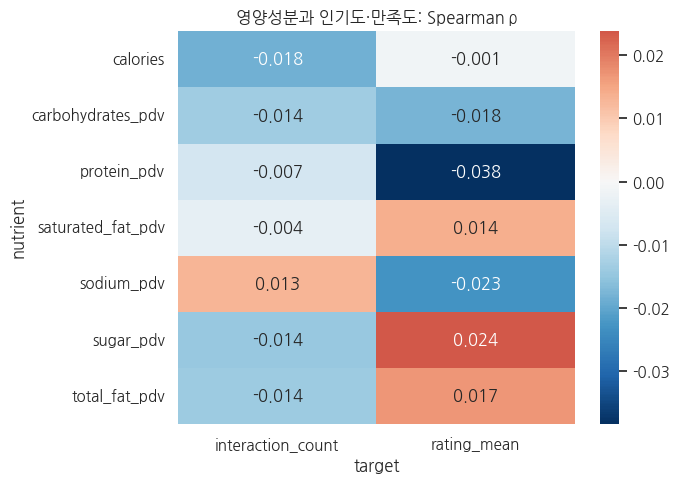

In [76]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(nutrition_correlations.pivot(index='nutrient', columns='target', values='rho'),
            annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('영양성분과 인기도·만족도: Spearman ρ')
fig.tight_layout()
save_figure(fig, '07_nutrition_correlation')
plt.show()

#### 영양 그룹별 만족도 분포

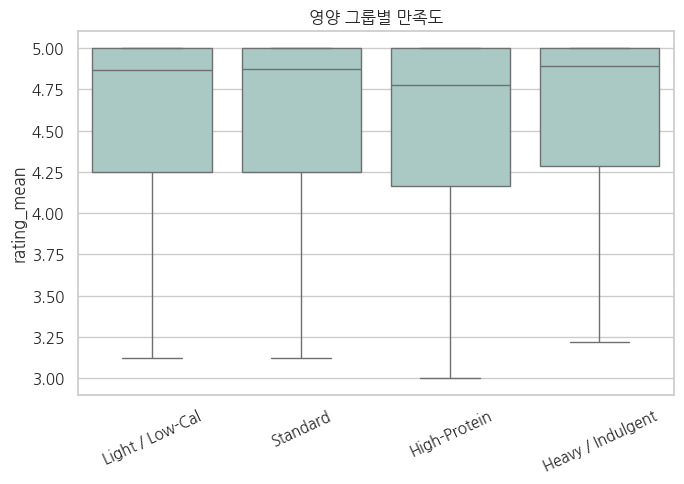

In [77]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=nutrition_analysis, x='nutrition_group', y='rating_mean', showfliers=False, ax=ax, color='#a5cec8')
ax.set_title('영양 그룹별 만족도')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
save_figure(fig, '07_nutrition_satisfaction')
plt.show()

#### 영양 그룹별 인기도 분포

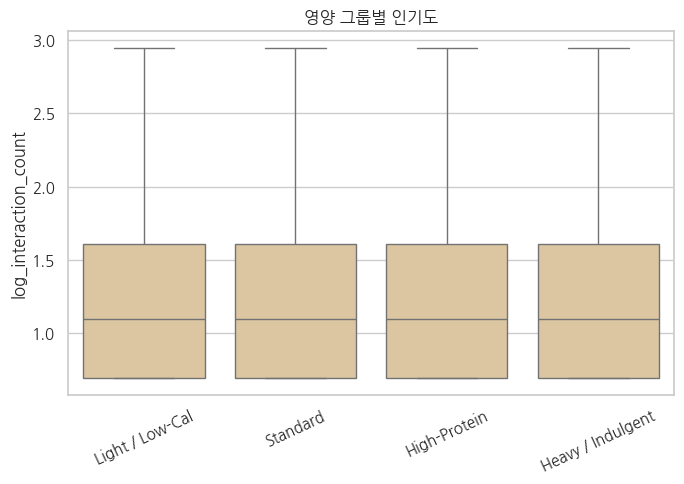

p값과 함께 ρ·epsilon_squared 및 그룹 간 실제 차이를 확인합니다.


In [78]:
plot_nutrition = nutrition_analysis.assign(log_interaction_count=np.log1p(nutrition_analysis['interaction_count']))
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=plot_nutrition, x='nutrition_group', y='log_interaction_count', showfliers=False, ax=ax, color='#e6c897')
ax.set_title('영양 그룹별 인기도')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
save_figure(fig, '07_nutrition_popularity')
plt.show()
print('p값과 함께 ρ·epsilon_squared 및 그룹 간 실제 차이를 확인합니다.')

## 4️⃣ 모델링

### 4-1. 추천 데이터
분석용 데이터는 유지하고, 새 모델 기준으로 추천에서는 0분을 제외한다.


In [79]:
import re
from collections import defaultdict
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, normalize
from sklearn.metrics.pairwise import cosine_similarity
model_recipes = recipes.copy()
model_recipes['minutes_rec'] = model_recipes['minutes'].replace(0, np.nan)
model_recipes['bayesian_rating_rec'] = model_recipes['bayesian_rating'].fillna(model_recipes['bayesian_rating'].mean())
model_recipes = model_recipes.loc[model_recipes['minutes_rec'].between(1, 60)].reset_index(drop=True)
print('분석 레시피:', len(recipes), '/ 추천 레시피:', len(model_recipes))

분석 레시피: 168090 / 추천 레시피: 168035


### 4-2. 재료 표기 정규화


In [80]:
BASE_ALIASES = {
    "eggs": "egg", "egg whites": "egg white", "egg yolks": "egg yolk",
    "onions": "onion", "diced onion": "onion", "red onions": "red onion",
    "yellow onions": "yellow onion", "white onions": "white onion",
    "sweet onions": "sweet onion", "green onions": "green onion",
    "eggplants": "eggplant", "shredded cheddar cheese": "cheddar cheese",
}

In [81]:
def normalize_base(name):
    s = " ".join(str(name).lower().strip().split())
    return BASE_ALIASES.get(s, s)

In [82]:
model_recipes["ing_base"] = model_recipes["ingredients_list"].apply(
    lambda xs: [normalize_base(i) for i in xs]
)
base_counts = model_recipes["ing_base"].explode().value_counts()
PREP_MODIFIERS = [
    "finely chopped", "coarsely chopped", "thinly sliced", "freshly ground",
    "boneless skinless", "extra large", "extra virgin",
    "fresh", "freshly", "raw", "whole", "large", "small", "medium",
    "chopped", "diced", "minced", "sliced", "grated", "shredded",
    "peeled", "crushed", "ripe", "cooked", "uncooked", "boneless",
    "skinless", "lean", "jumbo", "baby",
]
UNIT_SUFFIXES = [
    "cloves", "clove", "ribs", "rib", "stalks", "stalk",
    "halves", "half", "pieces", "piece", "heads", "head",
    "sprigs", "sprig", "leaves", "leaf",
]
CANNED_LIKE = re.compile(
    r"^(diced|crushed|chopped|stewed|whole) (tomatoes?|pineapple|peaches?|pears?)$"
)
COOC_THRESHOLD = 8.0
MIN_BASE_COUNT = 20

In [83]:
def derive_bases(variant):
    out = []
    if variant.endswith("es") and len(variant) > 4:
        out.append(variant[:-2])
    if variant.endswith("s") and len(variant) > 3:
        out.append(variant[:-1])
    for m in PREP_MODIFIERS:
        if variant.startswith(m + " "):
            out.append(variant[len(m) + 1:])
    for u in UNIT_SUFFIXES:
        if variant.endswith(" " + u):
            out.append(variant[: -(len(u) + 1)])
    return out

In [84]:
ingredient_recipes = defaultdict(set)
for i, ings in enumerate(model_recipes["ing_base"]):
    for ing in ings:
        ingredient_recipes[ing].add(i)
ingredient_count = {k: len(v) for k, v in ingredient_recipes.items()}
vocabulary = set(ingredient_count)
rows = []
for variant in sorted(vocabulary):
    if CANNED_LIKE.match(variant):
        continue
    for base in derive_bases(variant):
        if base == variant or base not in vocabulary:
            continue
        if ingredient_count[base] < MIN_BASE_COUNT:
            continue
        v_set, b_set = ingredient_recipes[variant], ingredient_recipes[base]
        rows.append({
            "variant": variant, "base": base,
            "v_n": ingredient_count[variant], "b_n": ingredient_count[base],
            "cooc": len(v_set & b_set) / len(v_set) * 100,
        })
candidates_df = pd.DataFrame(rows, columns=['variant', 'base', 'v_n', 'b_n', 'cooc'])
candidates_df = candidates_df[candidates_df["cooc"] < COOC_THRESHOLD]
candidates_df = candidates_df.sort_values(["variant", "b_n", "base"], ascending=[True, False, True])
raw_map = {v: g.iloc[0]["base"] for v, g in candidates_df.groupby("variant")}

In [85]:
def resolve_chain(name, seen=None):
    seen = seen or set()
    if name in seen or name not in raw_map:
        return name
    seen.add(name)
    return resolve_chain(raw_map[name], seen)

In [86]:
MERGE_MAP = {v: resolve_chain(v) for v in raw_map}
MERGE_MAP = {v: b for v, b in MERGE_MAP.items() if v != b}

In [87]:
def normalize_model_ingredient(name):
    s = normalize_base(name)
    return MERGE_MAP.get(s, s)

In [88]:
model_recipes["ing"] = model_recipes["ingredients_list"].apply(
    lambda xs: [normalize_model_ingredient(i) for i in xs]
)
model_recipes["ingredient_set"] = model_recipes["ing"].apply(set)
ingredient_counts = model_recipes["ing"].explode().value_counts()

In [89]:
print('정규화 매핑:', len(MERGE_MAP))
display(candidates_df.head(10))

정규화 매핑: 926


,variant,base,v_n,b_n,cooc
0,"9"" unbaked pie shells","9"" unbaked pie shell",1,25,0.000000
1,9-inch graham cracker crusts,9-inch graham cracker crust,3,24,0.000000
2,9-inch pie shells,9-inch pie shell,12,21,0.000000
3,alfalfa sprouts,alfalfa sprout,23,111,0.000000
4,anaheim chilies,anaheim chili,58,27,1.724138
5,anchovy fillets,anchovy fillet,222,28,0.000000
6,andouille sausages,andouille sausage,49,49,0.000000
7,anise seeds,anise seed,13,99,0.000000
8,apples,apple,1292,1203,0.851393
9,apricot halves,apricot,31,44,0.000000


### 4-3. 기본 양념과 수급 난이도
추천에는 새 모델의 팬트리 기준을 적용한다. 앞의 한계 효용 검정은 기존 10종 가정이다.


In [90]:
PANTRY_EXACT = {
    "salt", "sea salt", "kosher salt", "coarse salt", "table salt",
    "fine salt", "coarse kosher salt", "fine sea salt",
    "salt and pepper", "salt & pepper", "salt and black pepper",
    "salt & freshly ground black pepper", "salt and freshly ground black pepper",
    "pepper", "black pepper", "white pepper", "ground pepper",
    "ground black pepper", "fresh ground black pepper", "fresh ground pepper",
    "cracked black pepper", "fresh coarse ground black pepper",
    "freshly ground black pepper", "coarse black pepper",
    "sugar", "granulated sugar", "white sugar", "caster sugar",
    "water", "cold water", "warm water", "hot water", "boiling water",
    "ice", "ice cubes", "ice cube", "ice water", "lukewarm water",
    "oil", "vegetable oil", "cooking oil", "canola oil", "cooking spray",
    "salad oil", "corn oil", "nonstick cooking spray",
    "vegetable oil cooking spray",
}
PANTRY_PATTERNS = [re.compile(r"\b(soy sauce|soya sauce|tamari)\b")]

In [91]:
def is_pantry(name):
    if name in PANTRY_EXACT:
        return True
    return any(p.search(name) for p in PANTRY_PATTERNS)

In [92]:
KOREA_TIER_RULES = [
    (4, [
        "bisquick", "cool whip", "crisco", "shortening", "cream of tartar",
        "corn syrup", "karo", "graham cracker", "jell-o", "jello",
        "velveeta", "splenda", "liquid smoke", "old bay", "poultry seasoning",
        "pumpkin pie spice", "cake mix", "pie crust", "canned pumpkin",
        "molasses", "buttermilk", "half-and-half", "half and half",
        "evaporated milk", "cream of mushroom soup", "cream of chicken soup",
        "cream of celery soup", "marshmallow", "self-rising flour",
        "self rising flour", "cajun seasoning", "taco seasoning",
        "ranch dressing", "onion soup mix", "butterscotch",
        "wheat germ", "vanilla pudding", "instant pudding", "brown gravy mix",
        "biscuit mix", "cornbread mix", "food coloring", "candied",
        "mincemeat", "golden syrup", "treacle", "suet", "clotted cream",
    ]),
    (3, [
        "sour cream", "heavy cream", "whipping cream", "double cream",
        "ricotta", "feta", "blue cheese", "goat cheese", "monterey jack",
        "provolone", "swiss cheese", "parmesan", "cottage cheese",
        "mascarpone", "gruyere", "romano", "asiago", "havarti", "brie",
        "creme fraiche",
        "dijon", "worcestershire", "balsamic", "capers", "anchovy",
        "tahini", "pesto", "horseradish", "tartar sauce", "chutney",
        "sherry", "vermouth", "marsala", "miracle whip", "vinaigrette",
        "fresh basil", "fresh cilantro", "fresh dill", "fresh rosemary",
        "fresh thyme", "fresh oregano", "fresh mint", "fresh tarragon",
        "fresh sage", "fresh marjoram", "chives", "tarragon", "marjoram",
        "watercress", "arugula", "sorrel",
        "allspice", "cardamom", "garam masala", "saffron", "juniper",
        "star anise", "fennel seed", "caraway", "mace", "sumac",
        "celery seed", "celery salt", "mustard seed", "coriander seed",
        "artichoke", "asparagus", "shallot", "fennel", "brussels sprout",
        "jalapeno", "cilantro", "endive", "leek", "rutabaga",
        "parsnip", "turnip", "okra", "cranberries", "cranberry",
        "blackberries", "raspberries", "rhubarb", "pomegranate",
        "plantain", "persimmon", "papaya", "guava",
        "tortilla", "pita", "couscous", "quinoa", "polenta", "bulgur",
        "pine nuts", "pecans", "hazelnut", "pistachio", "macadamia",
        "buckwheat", "semolina", "phyllo", "puff pastry",
        "white wine", "red wine", "dry wine", "brandy", "rum", "vodka",
        "bourbon", "whiskey", "kahlua", "liqueur", "cognac", "port wine",
    ]),
    (2, [
        "cheddar", "mozzarella", "cream cheese", "parmesan cheese",
        "yogurt", "whipped cream", "condensed milk", "butter",
        "bacon", "ham", "sausage", "shrimp", "salmon", "tuna",
        "ground beef", "ground pork", "ground turkey", "beef", "pork",
        "chicken broth", "beef broth", "vegetable broth", "chicken stock",
        "beef stock", "vegetable stock",
        "mayonnaise", "ketchup", "mustard", "hot sauce", "tabasco",
        "barbecue sauce", "chili sauce", "tomato sauce", "tomato paste",
        "olive oil", "sesame oil", "peanut oil", "vinegar",
        "oregano", "basil", "thyme", "rosemary", "paprika", "cumin",
        "curry powder", "chili powder", "cayenne", "nutmeg", "cinnamon",
        "turmeric", "bay leaf", "bay leaves", "italian seasoning",
        "vanilla", "cocoa", "chocolate", "honey", "maple syrup",
        "peanut butter", "jam", "raisins", "almonds", "walnuts",
        "oats", "oatmeal", "pasta", "spaghetti", "macaroni", "noodles",
        "bell pepper", "green pepper", "red pepper", "celery", "broccoli",
        "cauliflower", "zucchini", "eggplant", "avocado", "lettuce",
        "tomatoes", "tomato", "mushroom", "lemon", "lime", "orange",
        "apple", "banana", "strawberr", "blueberr", "pineapple",
        "sweet potato", "corn", "peas", "green beans", "beans",
        "chickpea", "lentil", "yeast", "baking powder", "baking soda",
        "cornstarch", "breadcrumb", "flour tortilla",
    ]),
    (1, [
        "egg", "milk", "onion", "garlic", "potato", "carrot", "rice",
        "bread", "flour", "green onion", "scallion", "cabbage", "cucumber",
        "spinach", "tofu", "kimchi", "gochujang", "gochugaru", "ramen",
        "sesame seed", "ginger", "red pepper flakes",
        "bean sprout", "perilla", "chicken", "fish sauce", "rice vinegar",
        "brown sugar", "powdered sugar", "icing sugar", "confectioners",
    ]),
]

In [93]:
COMPILED_TIER_RULES = [
    (tier, [re.compile(r"\b" + re.escape(kw)) for kw in kws])
    for tier, kws in KOREA_TIER_RULES
]

In [94]:
def frequency_base_tier(count):
    if count >= 10000:
        return 1
    if count >= 2000:
        return 2
    if count >= 300:
        return 3
    return 4

In [95]:
def assign_tier(name, count):
    if is_pantry(name):
        return 0
    for tier, patterns in COMPILED_TIER_RULES:
        if any(p.search(name) for p in patterns):
            return tier
    return frequency_base_tier(count)

In [96]:
INGREDIENT_TIER = {
    ing: assign_tier(ing, cnt) for ing, cnt in ingredient_counts.items()
}
PANTRY_SET = {i for i, t in INGREDIENT_TIER.items() if t == 0}

In [97]:
def tier_of(name):
    return INGREDIENT_TIER.get(name, 4)

In [98]:
TIER_DIFFICULTY = {0: 0.0, 1: 0.0, 2: 1 / 3, 3: 2 / 3, 4: 1.0}

In [99]:
display(pd.Series(INGREDIENT_TIER).value_counts().sort_index().rename('재료 수'))

,재료 수
0,67
1,1247
2,4074
3,1243
4,5916


### 4-4. 식사 후보와 메인 재료


In [100]:
NON_MEAL_COURSES = {"condiment", "beverage"}
COMPONENT_DISH_TYPES = {
    "sauce_dressing", "dip_spread", "marinade_rub", "filling_frosting",
    "jam_preserve", "seasoning_mix", "stuffing", "stock_broth",
    "pastry_dough", "cocktail_punch", "smoothie_shake",
}
NON_MEAL_TITLE_PAT = "|".join([
    r"^cooking\b", r"\bhow to\b", r"\btricks?\b", r"\bpeeling\b",
    r"\bdeterrent\b", r"\btechnique\b", r"\bdehydrat\w*",
    r"\bfreezing\b", r"\bcanning\b", r"\bsubstitute\b",
])
TIPS_PAT = r"\btips?\b"
MEAT_CUT_PAT = (
    r"\b(?:beef|beefsteak|sirloin|steak|tri[- ]?tip|pork|turkey|chicken|lamb)\b"
)

In [101]:
def is_meal_candidate(row):
    if set(row["course_category"]) & NON_MEAL_COURSES:
        return False
    if set(row["dish_type"]) & COMPONENT_DISH_TYPES:
        return False
    name = str(row["name"]).lower()
    if re.search(NON_MEAL_TITLE_PAT, name):
        return False
    if re.search(TIPS_PAT, name) and not re.search(MEAT_CUT_PAT, name):
        return False
    has_category = any(
        len(row[c]) > 0
        for c in ["course_category", "dish_type", "main_ingredient_group", "cuisine"]
    )
    if not has_category and row["n_ingredients"] <= 2:
        return False
    return True

In [102]:
model_recipes["is_meal_candidate"] = model_recipes.apply(is_meal_candidate, axis=1)
passed = int(model_recipes["is_meal_candidate"].sum())

In [103]:
INGREDIENT_GROUP_RULES = [
    ("chocolate_cocoa", [r"\bchocolate\b", r"\bcocoa\b", r"\bcacao\b"]),
    ("chicken",  [r"\bchicken\b", r"\bhen\b"]),
    ("turkey",   [r"\bturkey\b"]),
    ("beef",     [r"\bbeef\b", r"\bsteak\b", r"\bsirloin\b", r"\bbrisket\b",
                  r"\bveal\b", r"\btri[- ]?tip\b", r"\bporterhouse\b",
                  r"\bchuck roast\b", r"\bflank\b"]),
    ("pork",     [r"\bpork\b", r"\bbacon\b", r"\bham\b", r"\bsausage\b",
                  r"\bprosciutto\b", r"\bpancetta\b", r"\bchorizo\b",
                  r"\bribs?\b", r"\bspare ?ribs?\b"]),
    ("lamb",     [r"\blamb\b", r"\bmutton\b"]),
    ("fish",     [r"\bfish\b", r"\bsalmon\b", r"\btuna\b", r"\bcod\b",
                  r"\btilapia\b", r"\bhalibut\b", r"\btrout\b", r"\banchov"]),
    ("shellfish",[r"\bshrimp\b", r"\bprawn", r"\bcrab\b", r"\blobster\b",
                  r"\bscallop", r"\bclam", r"\bmussel", r"\boyster"]),
    ("egg",      [r"\begg\b", r"\beggs\b", r"\begg white\b", r"\begg yolk\b"]),
    ("soy_tofu", [r"\btofu\b", r"\btempeh\b", r"\bsoybean"]),
    ("legume",   [r"\bbeans?\b", r"\blentil", r"\bchickpea", r"\bpeas?\b"]),
    ("nuts_seeds",[r"\balmond", r"\bwalnut", r"\bpecan", r"\bcashew",
                   r"\bpeanut\b", r"\bpine nuts?\b", r"\bsunflower seed"]),
    ("dairy_cheese",[r"\bcheese\b", r"\bcheddar\b", r"\bmozzarella\b",
                     r"\bparmesan\b", r"\bfeta\b", r"\bricotta\b",
                     r"\byogurt\b", r"\bmilk\b", r"\bcream\b"]),
    ("potato",   [r"\bpotato", r"\bhash brown"]),
    ("grain_rice_pasta",[r"\brice\b", r"\bpasta\b", r"\bspaghetti\b",
                         r"\bnoodle", r"\bmacaroni\b", r"\bbread\b",
                         r"\bflour\b", r"\boats?\b", r"\boatmeal\b",
                         r"\btortilla", r"\bcouscous\b", r"\bquinoa\b"]),
    ("fruit",    [r"\bapple\b", r"\bbanana\b", r"\borange\b", r"\blemon\b",
                  r"\blime\b", r"\bberry\b", r"\bberries\b", r"\bstrawberr",
                  r"\bblueberr", r"\bpeach", r"\bpear\b", r"\bpineapple\b",
                  r"\bmango\b", r"\bgrape", r"\bcherry\b", r"\bcherries\b",
                  r"\braisin", r"\bavocado\b"]),
    ("vegetable",[r"\bonion\b", r"\bcarrot\b", r"\bcelery\b", r"\btomato",
                  r"\bspinach\b", r"\bbroccoli\b", r"\bcabbage\b",
                  r"\bmushroom", r"\bzucchini\b",
                  r"\bbell pepper\b", r"\bgreen pepper\b", r"\bred pepper\b",
                  r"\bsweet pepper\b", r"\bjalapeno\b", r"\bpoblano\b",
                  r"\bcucumber\b", r"\blettuce\b", r"\bcorn\b",
                  r"\bsquash\b", r"\beggplant\b", r"\bcauliflower\b",
                  r"\basparagus\b", r"\bleek\b", r"\bgreen onion\b",
                  r"\bscallion\b", r"\bpumpkin\b", r"\bbeet\b"]),
]

In [104]:
COMPILED_GROUP_RULES = [
    (g, [re.compile(p) for p in ps]) for g, ps in INGREDIENT_GROUP_RULES
]
SEASONING_PAT = re.compile(
    r"\b(powder|salt|sauce|syrup|extract|seasoning|spice|spices|vinegar|oil|"
    r"broth|stock|bouillon|paste|dressing|marinade|juice|zest|rind|peel|"
    r"essence|food coloring|flakes|mix|cube|cubes|"
    r"black pepper|white pepper|cayenne|peppercorns?)\b"
)

In [105]:
def ingredient_group(name):
    if SEASONING_PAT.search(name):
        return None
    for group, patterns in COMPILED_GROUP_RULES:
        if any(p.search(name) for p in patterns):
            return group
    return None

In [106]:
INGREDIENT_GROUP = {i: ingredient_group(i) for i in ingredient_counts.index}
model_recipes["core_set"] = model_recipes["ingredient_set"].apply(lambda x: x - PANTRY_SET)
model_recipes["main_ings_rule1_2"] = model_recipes["core_set"].apply(
    lambda xs: {i for i in xs if INGREDIENT_GROUP.get(i)}
)
model_recipes["sub_ings_rule1_2"] = model_recipes["core_set"].apply(
    lambda xs: {i for i in xs if not INGREDIENT_GROUP.get(i)}
)
total_docs = len(model_recipes)
ing_df_dict = {ing: cnt / total_docs for ing, cnt in ingredient_counts.items()}

In [107]:
def extract_main_rule2_only(ings, top_k=5, threshold_df=0.005):
    mains = set()
    for idx, ing in enumerate(ings):
        if idx < top_k and ing_df_dict.get(ing, 0) >= threshold_df and ing not in PANTRY_SET:
            mains.add(ing)
    return mains

In [108]:
model_recipes["main_ings_rule2"] = model_recipes["ing"].apply(extract_main_rule2_only)
model_recipes["sub_ings_rule2"] = model_recipes.apply(
    lambda r: r["core_set"] - r["main_ings_rule2"], axis=1
)
model_recipes["main_ings"] = model_recipes["main_ings_rule1_2"]
model_recipes["sub_ings"] = model_recipes["sub_ings_rule1_2"]

원본의 `rules_1_2`는 사전 기반, `rule2`는 등장 순서·빈도 기반 메인 재료 구분이다. 두 조건을 비교한다.


### 4-5. 재료 TF-IDF·Word2Vec·음식 분류


In [109]:
from gensim.models import Word2Vec

In [110]:
def to_token(name):
    return re.sub(r"[^\w-]+", "_", name).strip("_")

In [111]:
model_recipes["ing_tokens"] = model_recipes["ing"].apply(
    lambda xs: [to_token(i) for i in xs]
)
model_recipes["ingredient_text"] = model_recipes["ing_tokens"].apply(" ".join)
model_ingredient_vectorizer = TfidfVectorizer(
    lowercase=False, token_pattern=r"(?u)\b[\w-]+\b"
)
X_model_ingredient = model_ingredient_vectorizer.fit_transform(model_recipes["ingredient_text"])
tfidf_vocab = model_ingredient_vectorizer.get_feature_names_out()
W2V_DIM = 50
w2v_model = Word2Vec(
    sentences=model_recipes["ing_tokens"].tolist(),
    vector_size=W2V_DIM,
    window=3,
    min_count=1,
    workers=4,
    epochs=10,
    seed=42,
)
W = np.zeros((len(tfidf_vocab), W2V_DIM), dtype=np.float32)
for idx, token in enumerate(tfidf_vocab):
    if token in w2v_model.wv:
        W[idx] = w2v_model.wv[token]
X_w2v_raw = np.asarray(X_model_ingredient @ W)
X_w2v = normalize(X_w2v_raw - X_w2v_raw.mean(axis=0))

In [112]:
CATEGORY_COLUMNS = ["course_category", "dish_type",
                    "main_ingredient_group", "cuisine"]
category_matrices = [
    MultiLabelBinarizer(sparse_output=True).fit_transform(model_recipes[col])
    for col in CATEGORY_COLUMNS
]
X_model_category = hstack(category_matrices).tocsr()
INGREDIENT_WEIGHT = 1.0
W2V_WEIGHT = 1.0
CATEGORY_WEIGHT = 0.5
X_model_content = hstack([
    X_model_ingredient * INGREDIENT_WEIGHT,
    csr_matrix(X_w2v) * W2V_WEIGHT,
    X_model_category * CATEGORY_WEIGHT,
]).tocsr()
model_id_to_idx = pd.Series(model_recipes.index, index=model_recipes["id"])

In [113]:
print('콘텐츠 행렬:', X_model_content.shape)
assert model_recipes.index.equals(pd.RangeIndex(len(model_recipes)))
assert model_recipes['id'].is_unique

콘텐츠 행렬: (168035, 12769)


### 4-6. 처음 취향 선택: k=16
EDA의 k=6과 별도로 학습한다 (k=6은 간단 시각화용, k=16이 우리의 추천 시스템을 위해서 필요한 클러스터)    
EDA에서 만든 재료 벡터를 재사용하고, 새 모델의 식사 후보에서 대표 메뉴를 고른다.


In [114]:
TASTE_CLUSTER_K = 16
TASTE_CLUSTER_NAMES = {}
taste_cluster_model = KMeans(n_clusters=TASTE_CLUSTER_K, n_init=10, random_state=SEED).fit(Z_ingredient)
taste_clusters = cluster_input[['id']].copy()
taste_clusters['taste_cluster'] = taste_cluster_model.labels_
taste_clusters['taste_center_distance'] = np.linalg.norm(
    Z_ingredient - taste_cluster_model.cluster_centers_[taste_cluster_model.labels_], axis=1
)
model_recipes = model_recipes.merge(taste_clusters, on='id', how='left', validate='one_to_one')
assert model_recipes['id'].tolist() == model_id_to_idx.index.tolist()
assert model_recipes['taste_cluster'].notna().all()
taste_clusters.to_csv(OUTPUT_DIR / 'recipe_clusters_taste_k16.csv', index=False)

In [115]:
taste_candidates = (
    model_recipes.loc[model_recipes['is_meal_candidate'] & model_recipes['main_ings'].map(bool)]
    .sort_values(['taste_cluster', 'taste_center_distance', 'id'])
    .drop_duplicates('name').groupby('taste_cluster', group_keys=False).head(3).copy()
)
taste_candidates['cluster_label'] = taste_candidates['taste_cluster'].map(lambda c: TASTE_CLUSTER_NAMES.get(c, f'군집 {int(c) + 1}'))
display(taste_candidates[['cluster_label', 'id', 'name', 'minutes_rec', 'ing']])
export_recipes(taste_candidates, OUTPUT_DIR / 'taste_menu_candidates_v4.csv')

,cluster_label,id,name,minutes_rec,ing
109049,군집 1,37825,oven scrambled eggs for a crowd,45.0,"[butter, egg, salt, milk]"
61291,군집 1,118047,fluffy oven scrambled eggs,30.0,"[butter, egg, salt, milk]"
135646,군집 1,320182,simple scrambled eggs,15.0,"[egg, milk, butter, salt]"
56296,군집 2,310914,easy yellow rice,30.0,"[yellow rice mix, vegetable broth, olive oil, cooking sherry, roasted red pepper, green olives]"
155984,군집 2,88697,tomato sausage and emmental croissants,17.0,"[sausage, olive oil, plum tomato, dried chili pepper flakes, creme fraiche, plain croissants, em..."
126338,군집 2,291765,riso verde green rice,30.0,"[olive oil, spring onion, long-grain white rice, reduced-sodium chicken broth, frozen spinach, f..."
166490,군집 3,241289,you ve gotta try these nachos,35.0,"[corn tortilla chips, tomatoes, jalapeno pepper, white onion, cilantro, olive oil, garlic, onion..."
83509,군집 3,389618,johnny jalapeno s chicken tortilla soup,30.0,"[vegetable oil, onion, garlic, chicken breast, cilantro, corn tortilla, chicken stock, rotel tom..."
70194,군집 3,225334,green chile enchilada casserole,35.0,"[green enchilada sauce, corn tortilla, chicken breast, bell pepper, onion, frozen corn, garlic, ..."
136547,군집 4,99435,skor bar sugar cookies,22.0,"[sugar, butter, vanilla, egg, all-purpose flour, baking powder, baking soda, salt, skor english ..."


In [116]:
LIKED_RECIPE_IDS = []  # 대표 메뉴 표에서 ID 1~3개 선택

### 4-7. 후보 필터와 취향 점수


In [117]:
def contains_excluded(ingredient_set, excluded_set):
    for ing in ingredient_set:
        for ex in excluded_set:
            if re.search(r"\b" + re.escape(ex) + r"\b", ing):
                return True
    return False

In [118]:
def build_candidates(owned_raw, excluded_raw, max_min, max_extra, liked_id=None, rule_type='rules_1_2'):
    if rule_type not in {'rules_1_2', 'rule2'}:
        raise ValueError('rule_type을 확인하세요.')
    if not 0 < max_min <= 60 or not isinstance(max_extra, int) or max_extra < 0:
        raise ValueError('조리시간은 1~60분, 추가 구매 수는 0 이상입니다.')
    liked_ids = [] if liked_id is None else ([int(liked_id)] if np.isscalar(liked_id) else list(dict.fromkeys(map(int, liked_id))))
    unknown = [rid for rid in liked_ids if rid not in model_id_to_idx.index]
    if unknown:
        raise ValueError(f'추천 대상에 없는 선호 ID: {unknown}')
    owned = {normalize_model_ingredient(i) for i in owned_raw}
    excluded = {normalize_model_ingredient(i) for i in excluded_raw}
    main_col = "main_ings_rule1_2" if rule_type == 'rules_1_2' else "main_ings_rule2"
    has_excluded = (
        model_recipes["ingredient_set"].apply(lambda s: contains_excluded(s, excluded))
        if excluded else pd.Series(False, index=model_recipes.index)
    )
    missing = model_recipes["core_set"].apply(lambda x: sorted(x - owned))
    missing_n = missing.apply(len)
    owned_main = model_recipes[main_col].apply(lambda x: len(x & owned))
    mask = (
        model_recipes["is_meal_candidate"]
        & model_recipes["minutes_rec"].notna()
        & (model_recipes["minutes_rec"] <= max_min)
        & (~has_excluded)
        & (missing_n <= max_extra)
        & (owned_main >= 1)
    )
    if liked_ids:
        mask &= ~model_recipes["id"].isin(liked_ids)
    candidates = model_recipes[mask].copy()
    if len(candidates) == 0:
        for col in ["missing_core", "missing_count", "owned_main_count", "owned_core_count",
                    "utilization", "match_ratio", "purchase_cost", "max_missing_tier",
                    "time_score", "rating_score", "preference_score"]:
            candidates[col] = []
        return candidates, owned
    candidates["missing_core"] = missing[mask]
    candidates["missing_count"] = missing_n[mask]
    candidates["owned_main_count"] = owned_main[mask]
    candidates["owned_core_count"] = candidates["core_set"].apply(lambda x: len(x & owned))
    candidates["utilization"] = candidates["owned_core_count"] / max(len(owned), 1)
    candidates["match_ratio"] = candidates["core_set"].apply(
        lambda x: len(x & owned) / len(x) if x else 1.0)
    candidates["purchase_cost"] = candidates["missing_core"].apply(
        lambda xs: sum(1.0 + TIER_DIFFICULTY[tier_of(i)] for i in xs))
    candidates["max_missing_tier"] = candidates["missing_core"].apply(
        lambda xs: max((tier_of(i) for i in xs), default=0))
    candidates["time_score"] = (1 - candidates["minutes_rec"] / max_min).clip(0, 1)
    candidates["rating_score"] = ((candidates["bayesian_rating_rec"] - 1) / 4).clip(0, 1)
    if liked_ids:
        candidates["preference_score"] = cosine_similarity(
            X_model_content[model_id_to_idx.loc[liked_ids].to_numpy()], X_model_content
        ).mean(axis=0)[candidates.index]
    else:
        candidates["preference_score"] = 0.0
    return candidates, owned

### 4-8. 추천 점수와 트랙 분리
트랙 A는 바로 조리, 트랙 B는 추가 구매가 필요한 메뉴다.


In [119]:
FINAL_WEIGHTS = {
    "ingredient_score": 0.30,
    "purchase_score": 0.25,
    "preference_score": 0.20,
    "rating_score": 0.15,
    "time_score": 0.10,
}

In [120]:
def diversify(candidates, top_k=10, pool_size=100, relevance_weight=0.9):
    pool = candidates.sort_values("final_score", ascending=False).head(pool_size).copy()
    remaining, selected = list(pool.index), []
    while remaining and len(selected) < top_k:
        if not selected:
            best = remaining[0]
        else:
            sims = cosine_similarity(
                X_model_content[remaining], X_model_content[selected]).max(axis=1)
            best, best_mmr = None, -np.inf
            for pos, idx in enumerate(remaining):
                mmr = (relevance_weight * pool.loc[idx, "final_score"]
                       - (1 - relevance_weight) * sims[pos])
                if mmr > best_mmr:
                    best_mmr, best = mmr, idx
        selected.append(best)
        remaining.remove(best)
    return pool.loc[selected]

In [121]:
def score_tracks(candidates, max_extra=2, use_preference=True, top_k=10):
    wa = {"ingredient_score": .30, "preference_score": .20,
          "rating_score": .15, "time_score": .10}
    wb = dict(FINAL_WEIGHTS)
    if not use_preference:
        wa.pop("preference_score")
        wb.pop("preference_score")
    wa = {k: v / sum(wa.values()) for k, v in wa.items()}
    wb = {k: v / sum(wb.values()) for k, v in wb.items()}
    a = candidates[candidates["missing_count"] == 0].copy()
    a_top = None
    if len(a) > 0:
        a["ingredient_score"] = a["utilization"]
        a["final_score"] = sum(a[k] * v for k, v in wa.items())
        a_top = diversify(a, top_k=top_k)
    b = candidates[candidates["missing_count"] >= 1].copy()
    b_top = None
    if len(b) > 0:
        b["ingredient_score"] = .5 * b["match_ratio"] + .5 * b["utilization"]
        b["purchase_score"] = (
            1 - b["purchase_cost"] / (max_extra * 2.0)).clip(0, 1)
        b["final_score"] = sum(b[k] * v for k, v in wb.items())
        b_top = diversify(b, top_k=top_k)
    return a_top, b_top

In [122]:
def get_final_recommendations(user_input, rule_type='rules_1_2', top_k=10):
    max_min = user_input.get("max_minutes", 60)
    max_extra = user_input.get("max_extra_ingredients", 2)
    liked_id = user_input.get("liked_recipe_id", None)
    use_pref = liked_id is not None and (np.isscalar(liked_id) or len(liked_id) > 0)
    candidates, owned_set = build_candidates(
        owned_raw=user_input["owned_ingredients"],
        excluded_raw=user_input["excluded_ingredients"],
        max_min=max_min,
        max_extra=max_extra,
        liked_id=liked_id,
        rule_type=rule_type
    )
    if len(candidates) == 0:
        print("조건을 만족하는 추천 후보 레시피가 없습니다.")
        return None, None
    track_a, track_b = score_tracks(
        candidates=candidates,
        max_extra=max_extra,
        use_preference=use_pref,
        top_k=top_k
    )
    return track_a, track_b

### 4-9. 사용자 조건과 기본·취향 추천


In [123]:
USER_INPUT = {
    'owned_ingredients': ['egg', 'onion', 'milk', 'cheddar cheese', 'bread'],
    'excluded_ingredients': ['shrimp'],
    'max_minutes': 60,
    'max_extra_ingredients': 2,
    'liked_recipe_id': LIKED_RECIPE_IDS or None
}
RULE_TYPE = 'rules_1_2'
RESULT_COLS = ['id', 'name', 'minutes_rec', 'missing_core', 'owned_main_count', 'bayesian_rating_rec', 'preference_score', 'final_score']
def show_tracks(track_a, track_b):
    for label, result in [('A: 지금 바로 조리', track_a), ('B: 추가 구매 후 조리', track_b)]:
        print(label)
        if result is None or result.empty:
            print('조건에 맞는 메뉴 없음')
        else:
            display(result[RESULT_COLS])

In [124]:
basic_input = dict(USER_INPUT, liked_recipe_id=None)
basic_a, basic_b = get_final_recommendations(basic_input, rule_type=RULE_TYPE, top_k=10)
show_tracks(basic_a, basic_b)

A: 지금 바로 조리


,id,name,minutes_rec,missing_core,owned_main_count,bayesian_rating_rec,preference_score,final_score
40849,439095,coffee cup scramble,4.0,[],3,4.868733,0.0,0.760747
136194,11554,sizzling french toast,15.0,[],3,4.693710,0.0,0.715480
83358,131426,jim s microwave scrambled eggs,9.0,[],3,4.717183,0.0,0.735262
61282,208896,fluffy melty scrambled eggz,12.0,[],3,4.360376,0.0,0.701844
135150,293752,simple bird nest,3.0,[],2,4.693710,0.0,0.642753
85455,271545,kittencal s perfect poached eggs,7.0,[],2,4.821870,0.0,0.639370
106832,419582,one eyed monsters,10.0,[],2,4.816226,0.0,0.629894
13332,201097,basic omelet,8.0,[],2,4.693710,0.0,0.627601
57198,359793,eggs shaken not stirred,15.0,[],2,4.693710,0.0,0.606389
117170,280471,poached egg,2.0,[],1,4.816226,0.0,0.545046


B: 추가 구매 후 조리


,id,name,minutes_rec,missing_core,owned_main_count,bayesian_rating_rec,preference_score,final_score
58313,291901,extra tasty scrambled eggs,10.0,[butter],4,4.756761,0.0,0.788598
47230,362716,crispy carrots,10.0,[carrot],2,4.693710,0.0,0.711684
101373,258084,muffin eggs,21.0,[frozen peppers and onions],3,4.693710,0.0,0.741893
13246,124131,basic crepes mix in blender,5.0,[flour],2,4.693710,0.0,0.722101
68567,68914,grandma s easy french toast,7.0,[vanilla extract],3,4.360376,0.0,0.729393
114293,146286,pepper cheese scramble,10.0,[green pepper],3,4.693710,0.0,0.738768
56625,96815,egg fried bread,8.0,[butter],3,4.675681,0.0,0.742089
28204,146058,cheddar tomato eggs,15.0,[diced tomatoes],3,4.615618,0.0,0.724690
107016,227845,onion sandwich,3.0,[mayonnaise],2,4.816226,0.0,0.705969
78237,120538,hootsla egg bread,13.0,[butter],3,4.770282,0.0,0.736107


In [125]:
personal_a, personal_b = get_final_recommendations(USER_INPUT, rule_type=RULE_TYPE, top_k=10)
show_tracks(personal_a, personal_b)
if not LIKED_RECIPE_IDS:
    print('선호 메뉴를 선택하면 취향 점수가 반영됩니다.')

A: 지금 바로 조리


,id,name,minutes_rec,missing_core,owned_main_count,bayesian_rating_rec,preference_score,final_score
40849,439095,coffee cup scramble,4.0,[],3,4.868733,0.0,0.760747
136194,11554,sizzling french toast,15.0,[],3,4.693710,0.0,0.715480
83358,131426,jim s microwave scrambled eggs,9.0,[],3,4.717183,0.0,0.735262
61282,208896,fluffy melty scrambled eggz,12.0,[],3,4.360376,0.0,0.701844
135150,293752,simple bird nest,3.0,[],2,4.693710,0.0,0.642753
85455,271545,kittencal s perfect poached eggs,7.0,[],2,4.821870,0.0,0.639370
106832,419582,one eyed monsters,10.0,[],2,4.816226,0.0,0.629894
13332,201097,basic omelet,8.0,[],2,4.693710,0.0,0.627601
57198,359793,eggs shaken not stirred,15.0,[],2,4.693710,0.0,0.606389
117170,280471,poached egg,2.0,[],1,4.816226,0.0,0.545046


B: 추가 구매 후 조리


,id,name,minutes_rec,missing_core,owned_main_count,bayesian_rating_rec,preference_score,final_score
58313,291901,extra tasty scrambled eggs,10.0,[butter],4,4.756761,0.0,0.788598
47230,362716,crispy carrots,10.0,[carrot],2,4.693710,0.0,0.711684
101373,258084,muffin eggs,21.0,[frozen peppers and onions],3,4.693710,0.0,0.741893
13246,124131,basic crepes mix in blender,5.0,[flour],2,4.693710,0.0,0.722101
68567,68914,grandma s easy french toast,7.0,[vanilla extract],3,4.360376,0.0,0.729393
114293,146286,pepper cheese scramble,10.0,[green pepper],3,4.693710,0.0,0.738768
56625,96815,egg fried bread,8.0,[butter],3,4.675681,0.0,0.742089
28204,146058,cheddar tomato eggs,15.0,[diced tomatoes],3,4.615618,0.0,0.724690
107016,227845,onion sandwich,3.0,[mayonnaise],2,4.816226,0.0,0.705969
78237,120538,hootsla egg bread,13.0,[butter],3,4.770282,0.0,0.736107


선호 메뉴를 선택하면 취향 점수가 반영됩니다.


### 4-10. 메인 재료 구분 규칙 비교


In [126]:
SCENARIOS = [
    ("Scenario A (계란 중심)", ["egg", "onion", "milk", "cheddar cheese", "bread"], ["shrimp"], 60),
    ("Scenario B (양념/부재료만 보유)", ["garlic", "soy sauce", "olive oil"], [], 60),
    ("Scenario C (채소 중심)", ["onion", "carrot", "potato", "cabbage"], [], 60),
    ("Scenario D (닭고기·밥)", ["chicken breast", "rice", "onion", "garlic"], [], 60),
    ("Scenario E (고기 제외)", ["chicken breast", "tomato", "onion", "garlic"], ["beef"], 60),
]

In [127]:
def calculate_noise_rate(recommendations, owned_set, rule_type):
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    main_col = "main_ings_rule1_2" if rule_type == 'rules_1_2' else "main_ings_rule2"
    noise_count = 0
    for _, row in recommendations.iterrows():
        main_ings = set(row[main_col])
        matched_mains = main_ings.intersection(owned_set)
        if len(main_ings) > 0 and len(matched_mains) == 0:
            noise_count += 1
    return round((noise_count / len(recommendations)) * 100, 2)

In [128]:
def evaluate_scenarios(scenarios, max_extra=2, top_k=10):
    comparison_rows = []
    for name, owned_raw, excluded_raw, max_min in scenarios:
        owned_set = {normalize_model_ingredient(i) for i in owned_raw}
        cand_b, _ = build_candidates(owned_raw, excluded_raw, max_min, max_extra, rule_type='rules_1_2')
        track_a_b, track_b_b = score_tracks(cand_b, max_extra, use_preference=False, top_k=top_k)
        noise_rate_b = calculate_noise_rate(track_b_b, owned_set, rule_type='rules_1_2')
        time_violation_b = int((track_b_b["minutes_rec"] > max_min).sum()) if (track_b_b is not None and not track_b_b.empty and "minutes_rec" in track_b_b.columns) else 0
        extra_violation_b = int((track_b_b["missing_count"] > max_extra).sum()) if (track_b_b is not None and not track_b_b.empty and "missing_count" in track_b_b.columns) else 0
        cand_a, _ = build_candidates(owned_raw, excluded_raw, max_min, max_extra, rule_type='rule2')
        track_a_a, track_b_a = score_tracks(cand_a, max_extra, use_preference=False, top_k=top_k)
        noise_rate_a = calculate_noise_rate(track_b_a, owned_set, rule_type='rule2')
        time_violation_a = int((track_b_a["minutes_rec"] > max_min).sum()) if (track_b_a is not None and not track_b_a.empty and "minutes_rec" in track_b_a.columns) else 0
        extra_violation_a = int((track_b_a["missing_count"] > max_extra).sum()) if (track_b_a is not None and not track_b_a.empty and "missing_count" in track_b_a.columns) else 0
        top_a_set = set(track_b_a['id'].head(5)) if (track_b_a is not None and not track_b_a.empty and 'id' in track_b_a.columns) else set()
        top_b_set = set(track_b_b['id'].head(5)) if (track_b_b is not None and not track_b_b.empty and 'id' in track_b_b.columns) else set()
        overlap_ratio = round(len(top_a_set & top_b_set) / max(len(top_b_set), 1) * 100, 1)
        comparison_rows.append({
            "시나리오": name,
            "후보수(규칙1+2)": len(cand_b),
            "후보수(규칙2)": len(cand_a),
            "Top5 중복률(%)": overlap_ratio,
            "노이즈율_규칙1+2(%)": noise_rate_b,
            "노이즈율_규칙2(%)": noise_rate_a,
            "시간위반(건)": time_violation_b,
            "구매위반(건)": extra_violation_b,
        })
    return pd.DataFrame(comparison_rows)

In [129]:
scenario_comparison = evaluate_scenarios(SCENARIOS, max_extra=2, top_k=10)
display(scenario_comparison)
scenario_comparison.to_csv(OUTPUT_DIR / 'scenario_comparison_v4.csv', index=False, encoding='utf-8-sig')

,시나리오,후보수(규칙1+2),후보수(규칙2),Top5 중복률(%),노이즈율_규칙1+2(%),노이즈율_규칙2(%),시간위반(건),구매위반(건)
0,Scenario A (계란 중심),2207,2185,100.0,0.0,0.0,0,0
1,Scenario B (양념/부재료만 보유),0,1123,0.0,0.0,0.0,0,0
2,Scenario C (채소 중심),774,767,100.0,0.0,0.0,0,0
3,Scenario D (닭고기·밥),572,804,100.0,0.0,0.0,0,0
4,Scenario E (고기 제외),476,704,100.0,0.0,0.0,0,0


노이즈율은 각 규칙의 메인 재료 정의로 계산한 내부 지표. 정답 라벨에 대한 정확도나 재현율은 아님


### 4-11. 장보기 추천
새로 가능한 메뉴 수가 많은 재료를 우선하고, 같으면 수급 난이도가 낮은 재료를 고른다.


In [130]:
def suggest_grocery_shopping(owned_raw, excluded_raw, max_min=60, top_n_ingredients=3, top_k_recipes=3):
    candidates, _ = build_candidates(owned_raw, excluded_raw, max_min, 1, rule_type='rules_1_2')
    candidates = candidates.loc[candidates['missing_count'].eq(1)].copy()
    columns = ['ingredient', 'new_recipes', 'tier', 'example_ids', 'example_names']
    if candidates.empty:
        return pd.DataFrame(columns=columns)
    candidates['purchase_ingredient'] = candidates['missing_core'].map(lambda items: items[0])
    summary = candidates.groupby('purchase_ingredient').size().rename('new_recipes').reset_index()
    summary = summary.rename(columns={'purchase_ingredient': 'ingredient'})
    summary['tier'] = summary['ingredient'].map(tier_of)
    summary = summary.sort_values(['new_recipes', 'tier', 'ingredient'], ascending=[False, True, True]).head(top_n_ingredients)
    ids, names = [], []
    for ingredient in summary['ingredient']:
        examples = candidates.loc[candidates['purchase_ingredient'].eq(ingredient)].sort_values(
            ['bayesian_rating_rec', 'id'], ascending=[False, True]
        ).head(top_k_recipes)
        ids.append(examples['id'].tolist())
        names.append(examples['name'].tolist())
    summary['example_ids'], summary['example_names'] = ids, names
    return summary[columns]

In [131]:
shopping_recommendations = suggest_grocery_shopping(
    USER_INPUT['owned_ingredients'], USER_INPUT['excluded_ingredients'], USER_INPUT['max_minutes']
)
display(shopping_recommendations)
export_recipes(shopping_recommendations, OUTPUT_DIR / 'shopping_recommendations_v4.csv')

,ingredient,new_recipes,tier,example_ids,example_names
72,flour,45,1,"[234811, 170083, 91311]","[grandma s swedish thin pancakes, kate s basic crepes, no fail homemade noodles]"
30,butter,43,2,"[37825, 352739, 375710]","[oven scrambled eggs for a crowd, bull s eye breakfast, fried eggs with onion ukrainian russian]"
1,all-purpose flour,17,1,"[170649, 215483, 424328]","[crisp fried onions stegte log, master recipe for pasta dough, wonton wrappers made at home]"


### 4-12. 결과 점검과 저장


In [132]:
for name, result in [('basic_a', basic_a), ('basic_b', basic_b), ('personal_a', personal_a), ('personal_b', personal_b)]:
    if result is None:
        continue
    assert result['minutes_rec'].le(USER_INPUT['max_minutes']).all()
    assert result['missing_count'].le(USER_INPUT['max_extra_ingredients']).all()
    assert result['id'].is_unique
    if name.endswith('_a'):
        assert result['missing_count'].eq(0).all()
    else:
        assert result['missing_count'].ge(1).all()
    excluded = {normalize_model_ingredient(item) for item in USER_INPUT['excluded_ingredients']}
    assert not result['ingredient_set'].map(lambda items: contains_excluded(items, excluded)).any()
    if name.startswith('personal'):
        assert not result['id'].isin(LIKED_RECIPE_IDS).any()
    export_recipes(result, OUTPUT_DIR / f'recommendations_v4_{name}.csv')
export_recipes(model_recipes, OUTPUT_DIR / 'recipes_model_v4.csv')
model_settings = {'model_source': '1BhprUVRAhqAZ7A4HiveyYKG0Gz5DxXnr', 'eda_k': CLUSTER_K,
                  'taste_k': TASTE_CLUSTER_K, 'rule_type': RULE_TYPE, 'weights': FINAL_WEIGHTS,
                  'user_input': USER_INPUT, 'model_rows': len(model_recipes)}
(OUTPUT_DIR / 'model_v4_settings.json').write_text(json.dumps(model_settings, ensure_ascii=False, indent=2), encoding='utf-8')

566

## 5️⃣ 추가 NLP EDA
MiniLM으로 태그·재료·설명을 묶어 본다


In [133]:
RUN_NLP_EDA = False
nlp_cluster_results = {}
if RUN_NLP_EDA:
    from sentence_transformers import SentenceTransformer
    embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
    tag_counts = Counter(tag for items in recipes['tags_list'] for tag in items)
    nlp_ingredient_counts = Counter(ingredient for items in recipes['ingredients_norm'] for ingredient in items)
    descriptions = recipes['description'].dropna()
    descriptions = descriptions.loc[descriptions.str.strip().ne('')]
    descriptions = descriptions.sample(min(2000, len(descriptions)), random_state=SEED)
    text_groups = {
        'tags': (sorted(tag_counts), 10),
        'ingredients': ([name for name, _ in nlp_ingredient_counts.most_common(500)], 12),
        'descriptions': (descriptions.tolist(), 8)
    }
    for name, (texts, k) in text_groups.items():
        if len(texts) <= k:
            print(name, ': 군집 분석 표본 부족')
            continue
        embedding_texts = [text.replace('-', ' ') for text in texts] if name == 'tags' else texts
        embeddings = embedding_model.encode(embedding_texts, batch_size=32, show_progress_bar=True)
        model = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(embeddings)
        result = pd.DataFrame({'text': texts, 'cluster': model.labels_})
        nlp_cluster_results[name] = result
        score = silhouette_score(embeddings, model.labels_, sample_size=min(2000, len(texts)), random_state=SEED)
        print(f'{name}: silhouette={score:.4f}')
        display(result.groupby('cluster')['text'].apply(lambda values: values.head(8).tolist()))
        result.to_csv(OUTPUT_DIR / f'nlp_{name}_clusters.csv', index=False, encoding='utf-8-sig')

#### 유사 재료 후보 함수


In [134]:
def similar_ingredient_candidates(ingredient, top_n=5):
    if 'ingredients' not in nlp_cluster_results:
        raise ValueError('RUN_NLP_EDA를 켜고 위 셀을 실행하세요.')
    frame = nlp_cluster_results['ingredients']
    match = frame.loc[frame['text'].eq(normalize_ingredient(ingredient)), 'cluster']
    if match.empty:
        return []
    return frame.loc[frame['cluster'].eq(match.iloc[0]) & frame['text'].ne(normalize_ingredient(ingredient)), 'text'].head(top_n).tolist()

유사 재료 후보는 실제 보유 재료와 별도로 확인한다
